In [5]:
import sys
import numpy as np
import scipy
import pandas as pd
import torch
import h5py
import sklearn
import hdbscan

print("Python      :", sys.version)
print("NumPy       :", np.__version__)
print("SciPy       :", scipy.__version__)
print("Pandas      :", pd.__version__)
print("PyTorch     :", torch.__version__)
print("HDF5        :", h5py.__version__)
print("Scikit-learn:", sklearn.__version__)
print("HDBSCAN     : INSTALLED")

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python      : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy       : 2.1.3
SciPy       : 1.16.3
Pandas      : 2.2.3
PyTorch     : 2.11.0+cu128
HDF5        : 3.16.0
Scikit-learn: 1.6.1
HDBSCAN     : INSTALLED

CUDA available: True
GPU: Tesla T4


In [6]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("No GPU detected.")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [7]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA: 12.8


In [8]:
!nvidia-smi

Fri Sep 25 00:06:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
import os
import subprocess

print("COLAB_GPU:", os.environ.get("COLAB_GPU"))
print("CUDA_HOME:", os.environ.get("CUDA_HOME"))
print("CUDA_PATH:", os.environ.get("CUDA_PATH"))

try:
    result = subprocess.run(
        ["lspci"],
        capture_output=True,
        text=True
    )
    print("\nPCI devices:")
    print(result.stdout[:5000])
except Exception as e:
    print("lspci check failed:", e)

COLAB_GPU: 1
CUDA_HOME: None
CUDA_PATH: None
lspci check failed: [Errno 2] No such file or directory: 'lspci'


In [10]:
import torch

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("CUDA version    :", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print("VRAM            :",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")

PyTorch version : 2.11.0+cu128
CUDA available  : True
CUDA version    : 12.8
GPU             : Tesla T4
VRAM            : 14.56 GB


In [11]:
from huggingface_hub import login

login()

In [12]:
from huggingface_hub import HfApi

api = HfApi()

repo_id = "alan-turing-institute/turing-synthetic-radar-dataset"

# Check logged-in account
user = api.whoami()

print("Logged-in Hugging Face account:")
print(user["name"])

print("\nChecking TSRD dataset access...")

try:
    info = api.dataset_info(repo_id)

    print("ACCESS: SUCCESS")
    print("Dataset :", repo_id)
    print("ID      :", info.id)
    print("Private :", info.private)

except Exception as e:
    print("ACCESS: FAILED")
    print(type(e).__name__)
    print(e)

Logged-in Hugging Face account:
saumiya01

Checking TSRD dataset access...
ACCESS: SUCCESS
Dataset : alan-turing-institute/turing-synthetic-radar-dataset
ID      : alan-turing-institute/turing-synthetic-radar-dataset
Private : False


In [13]:
from huggingface_hub import HfApi

api = HfApi()

repo_id = "alan-turing-institute/turing-synthetic-radar-dataset"

print("Fetching repository file list...\n")

files = api.list_repo_files(
    repo_id=repo_id,
    repo_type="dataset"
)

print("Total files:", len(files))
print("\nFirst 100 files:\n")

for i, file in enumerate(files[:100], 1):
    print(f"{i:3d}. {file}")

Fetching repository file list...

Total files: 9021

First 100 files:

  1. .gitattributes
  2. .gitignore
  3. README.md
  4. archive/test/test_0.h5
  5. archive/test/test_1.h5
  6. archive/test/test_10.h5
  7. archive/test/test_100.h5
  8. archive/test/test_101.h5
  9. archive/test/test_102.h5
 10. archive/test/test_103.h5
 11. archive/test/test_104.h5
 12. archive/test/test_105.h5
 13. archive/test/test_106.h5
 14. archive/test/test_107.h5
 15. archive/test/test_108.h5
 16. archive/test/test_109.h5
 17. archive/test/test_11.h5
 18. archive/test/test_110.h5
 19. archive/test/test_111.h5
 20. archive/test/test_112.h5
 21. archive/test/test_113.h5
 22. archive/test/test_114.h5
 23. archive/test/test_115.h5
 24. archive/test/test_116.h5
 25. archive/test/test_117.h5
 26. archive/test/test_118.h5
 27. archive/test/test_119.h5
 28. archive/test/test_12.h5
 29. archive/test/test_120.h5
 30. archive/test/test_121.h5
 31. archive/test/test_122.h5
 32. archive/test/test_123.h5
 33. archive/te

In [14]:
from huggingface_hub import HfApi

api = HfApi()

repo_id = "alan-turing-institute/turing-synthetic-radar-dataset"

files = api.list_repo_files(
    repo_id=repo_id,
    repo_type="dataset"
)

# Show only HDF5 files outside the archive directory
h5_files = [
    f for f in files
    if f.endswith(".h5") and not f.startswith("archive/")
]

print("Non-archive HDF5 files:", len(h5_files))
print()

for f in h5_files:
    print(f)

Non-archive HDF5 files: 6000

scan/test_scan/config_0.h5
scan/test_scan/config_1.h5
scan/test_scan/config_10.h5
scan/test_scan/config_100.h5
scan/test_scan/config_101.h5
scan/test_scan/config_102.h5
scan/test_scan/config_103.h5
scan/test_scan/config_104.h5
scan/test_scan/config_105.h5
scan/test_scan/config_106.h5
scan/test_scan/config_107.h5
scan/test_scan/config_108.h5
scan/test_scan/config_109.h5
scan/test_scan/config_11.h5
scan/test_scan/config_110.h5
scan/test_scan/config_111.h5
scan/test_scan/config_112.h5
scan/test_scan/config_113.h5
scan/test_scan/config_114.h5
scan/test_scan/config_115.h5
scan/test_scan/config_116.h5
scan/test_scan/config_117.h5
scan/test_scan/config_118.h5
scan/test_scan/config_119.h5
scan/test_scan/config_12.h5
scan/test_scan/config_120.h5
scan/test_scan/config_121.h5
scan/test_scan/config_122.h5
scan/test_scan/config_123.h5
scan/test_scan/config_124.h5
scan/test_scan/config_125.h5
scan/test_scan/config_126.h5
scan/test_scan/config_127.h5
scan/test_scan/confi

In [15]:
from huggingface_hub import HfApi

api = HfApi()

repo_id = "alan-turing-institute/turing-synthetic-radar-dataset"

files = api.list_repo_files(
    repo_id=repo_id,
    repo_type="dataset"
)

# Keep only HDF5 files containing "scan"
scan_files = [
    f for f in files
    if f.endswith(".h5") and "scan" in f.lower()
]

print("Total scan HDF5 files:", len(scan_files))
print()

for f in scan_files:
    print(f)

Total scan HDF5 files: 3000

scan/test_scan/config_0.h5
scan/test_scan/config_1.h5
scan/test_scan/config_10.h5
scan/test_scan/config_100.h5
scan/test_scan/config_101.h5
scan/test_scan/config_102.h5
scan/test_scan/config_103.h5
scan/test_scan/config_104.h5
scan/test_scan/config_105.h5
scan/test_scan/config_106.h5
scan/test_scan/config_107.h5
scan/test_scan/config_108.h5
scan/test_scan/config_109.h5
scan/test_scan/config_11.h5
scan/test_scan/config_110.h5
scan/test_scan/config_111.h5
scan/test_scan/config_112.h5
scan/test_scan/config_113.h5
scan/test_scan/config_114.h5
scan/test_scan/config_115.h5
scan/test_scan/config_116.h5
scan/test_scan/config_117.h5
scan/test_scan/config_118.h5
scan/test_scan/config_119.h5
scan/test_scan/config_12.h5
scan/test_scan/config_120.h5
scan/test_scan/config_121.h5
scan/test_scan/config_122.h5
scan/test_scan/config_123.h5
scan/test_scan/config_124.h5
scan/test_scan/config_125.h5
scan/test_scan/config_126.h5
scan/test_scan/config_127.h5
scan/test_scan/config

In [16]:
from huggingface_hub import hf_hub_download
import h5py
import os

REPO_ID = "alan-turing-institute/turing-synthetic-radar-dataset"

print("Downloading ONE scan training file...")
print("File: scan/train_scan/config_0.h5")

file_path = hf_hub_download(
    repo_id=REPO_ID,
    filename="scan/train_scan/config_0.h5",
    repo_type="dataset"
)

print("\nDownloaded to:")
print(file_path)

print("\nFile size:")
print(round(os.path.getsize(file_path) / (1024**2), 2), "MiB")

print("\nInspecting HDF5 structure...\n")

with h5py.File(file_path, "r") as f:

    print("Top-level keys:")
    print(list(f.keys()))

    print("\nDetailed structure:")

    def show_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(
                f"DATASET  {name}"
                f" | shape={obj.shape}"
                f" | dtype={obj.dtype}"
            )
        else:
            print(f"GROUP    {name}")

    f.visititems(show_structure)

File: scan/train_scan/config_0.h5


scan/train_scan/config_0.h5: reconstructing file:   0%|          |  0.00B / 3.63MB            

scan/train_scan/config_0.h5: downloading bytes:           |  0.00B            


Downloaded to:
/root/.cache/huggingface/hub/datasets--alan-turing-institute--turing-synthetic-radar-dataset/snapshots/68a07b0e0189c5b4ec748c4b66dedfe26f8f1c51/scan/train_scan/config_0.h5

File size:
3.46 MiB

Inspecting HDF5 structure...

Top-level keys:
['data', 'labels', 'metadata']

Detailed structure:
DATASET  data | shape=(169617, 5) | dtype=float32
DATASET  labels | shape=(169617, 1) | dtype=int8
GROUP    metadata
DATASET  metadata/feature_names | shape=(5,) | dtype=|S10
GROUP    metadata/receiver
DATASET  metadata/receiver/dwell_centres_mhz | shape=(36,) | dtype=float32
DATASET  metadata/receiver/dwell_times_s | shape=(36,) | dtype=float32
DATASET  metadata/receiver/freq_range_mhz | shape=(2,) | dtype=float32
DATASET  metadata/receiver/start_position_km | shape=(2,) | dtype=float32
GROUP    metadata/transmitters
GROUP    metadata/transmitters/transmitters_0
GROUP    metadata/transmitters/transmitters_0/frequency_config
DATASET  metadata/transmitters/transmitters_0/frequency_con

In [17]:
import h5py
import numpy as np

# Make sure file_path points to your downloaded config_0.h5
print("FILE:", file_path)

with h5py.File(file_path, "r") as f:

    # ============================================================
    # 1. FEATURE NAMES
    # ============================================================
    feature_names = f["metadata/feature_names"][:]

    feature_names = [
        x.decode("utf-8") if isinstance(x, bytes) else str(x)
        for x in feature_names
    ]

    print("\n" + "=" * 70)
    print("FEATURE NAMES")
    print("=" * 70)

    for i, name in enumerate(feature_names):
        print(f"Feature {i}: {name}")

    # ============================================================
    # 2. DATASET SHAPES
    # ============================================================
    print("\n" + "=" * 70)
    print("DATASET SHAPES")
    print("=" * 70)

    print("data shape   :", f["data"].shape)
    print("data dtype   :", f["data"].dtype)
    print("labels shape :", f["labels"].shape)
    print("labels dtype :", f["labels"].dtype)

    # ============================================================
    # 3. FIRST 10 DATA ROWS
    # ============================================================
    data = f["data"][:10]
    labels = f["labels"][:10].flatten()

    print("\n" + "=" * 70)
    print("FIRST 10 DATA ROWS")
    print("=" * 70)

    for i, row in enumerate(data):
        print(f"{i:2d}: {row}")

    print("\n" + "=" * 70)
    print("FIRST 10 LABELS")
    print("=" * 70)

    print(labels)

    # ============================================================
    # 4. FEATURE STATISTICS
    # ============================================================
    print("\n" + "=" * 70)
    print("FEATURE STATISTICS")
    print("=" * 70)

    all_data = f["data"]

    for i, name in enumerate(feature_names):

        column = all_data[:, i]

        print(
            f"{i}: {name:20s} | "
            f"min={column.min():12.6f} | "
            f"max={column.max():12.6f} | "
            f"mean={column.mean():12.6f} | "
            f"std={column.std():12.6f}"
        )

    # ============================================================
    # 5. LABEL DISTRIBUTION
    # ============================================================
    print("\n" + "=" * 70)
    print("LABEL DISTRIBUTION")
    print("=" * 70)

    all_labels = f["labels"][:].flatten()

    unique, counts = np.unique(all_labels, return_counts=True)

    total = len(all_labels)

    for label, count in zip(unique, counts):
        percentage = 100 * count / total

        print(
            f"Label {label:4d} : "
            f"{count:10,} samples "
            f"({percentage:7.2f}%)"
        )

    # ============================================================
    # 6. BASIC SANITY CHECKS
    # ============================================================
    print("\n" + "=" * 70)
    print("SANITY CHECKS")
    print("=" * 70)

    print("NaNs in data   :", np.isnan(all_data[:]).sum())
    print("Infs in data   :", np.isinf(all_data[:]).sum())
    print("NaNs in labels :", np.isnan(all_labels).sum())

    print("\nInspection complete.")

FILE: /root/.cache/huggingface/hub/datasets--alan-turing-institute--turing-synthetic-radar-dataset/snapshots/68a07b0e0189c5b4ec748c4b66dedfe26f8f1c51/scan/train_scan/config_0.h5

FEATURE NAMES
Feature 0: ToA
Feature 1: Frequency
Feature 2: PulseWidth
Feature 3: AoA
Feature 4: Amplitude

DATASET SHAPES
data shape   : (169617, 5)
data dtype   : float32
labels shape : (169617, 1)
labels dtype : int8

FIRST 10 DATA ROWS
 0: [ 2.0014253e+05  1.3963057e+03  1.4493292e+02  2.5857487e+01
 -1.0520895e+02]
 1: [ 2.3867053e+05  1.3962845e+03  1.9920037e+00  2.6245293e+01
 -1.0650539e+02]
 2: [ 2.5693334e+05  1.3946366e+03  1.0122957e+02  2.5864313e+01
 -1.0694468e+02]
 3: [ 2.63728062e+05  1.39491663e+03  2.15092178e+02  2.59507294e+01
 -1.15484344e+02]
 4: [ 2.6674288e+05  1.3959948e+03  1.9277492e+00  2.5809408e+01
 -1.0677876e+02]
 5: [ 2.7830922e+05  1.3965079e+03  2.0830130e+02  2.5567532e+01
 -1.1241711e+02]
 6: [ 2.7913800e+05  1.3965187e+03  1.9255040e+02  2.5417484e+01
 -1.0834248e+02]
 

In [18]:
import h5py
import numpy as np

with h5py.File(file_path, "r") as f:

    print("=" * 80)
    print("TOP-LEVEL STRUCTURE")
    print("=" * 80)

    def show_structure(name, obj):
        print(name, "->", type(obj).__name__)

    f.visititems(show_structure)

    print("\n" + "=" * 80)
    print("TRANSMITTER METADATA")
    print("=" * 80)

    transmitters = f["metadata/transmitters"]

    print("Transmitter object:", transmitters)
    print("Keys:", list(transmitters.keys()))

    for key in transmitters.keys():

        obj = transmitters[key]

        print("\n" + "-" * 60)
        print("TRANSMITTER:", key)
        print("-" * 60)

        if isinstance(obj, h5py.Group):

            print("Group keys:", list(obj.keys()))

            for subkey in obj.keys():

                value = obj[subkey]

                try:
                    data = value[:]

                    print(
                        f"{subkey:20s} | "
                        f"shape={data.shape} | "
                        f"dtype={data.dtype} | "
                        f"value={data}"
                    )

                except Exception:
                    print(
                        f"{subkey:20s} | "
                        f"{value}"
                    )

        else:
            try:
                print(obj[:])
            except Exception:
                print(obj)

TOP-LEVEL STRUCTURE
data -> Dataset
labels -> Dataset
metadata -> Group
metadata/feature_names -> Dataset
metadata/receiver -> Group
metadata/receiver/dwell_centres_mhz -> Dataset
metadata/receiver/dwell_times_s -> Dataset
metadata/receiver/freq_range_mhz -> Dataset
metadata/receiver/start_position_km -> Dataset
metadata/transmitters -> Group
metadata/transmitters/transmitters_0 -> Group
metadata/transmitters/transmitters_0/frequency_config -> Group
metadata/transmitters/transmitters_0/frequency_config/freqs_mhz -> Dataset
metadata/transmitters/transmitters_0/position_config -> Group
metadata/transmitters/transmitters_0/position_config/start_position_km -> Dataset
metadata/transmitters/transmitters_0/power_config -> Group
metadata/transmitters/transmitters_0/pri_config -> Group
metadata/transmitters/transmitters_0/pri_config/pris_us -> Dataset
metadata/transmitters/transmitters_0/pulse_width_config -> Group
metadata/transmitters/transmitters_0/pulse_width_config/pws_us -> Dataset
metad

In [19]:
import h5py
import numpy as np

with h5py.File(file_path, "r") as f:

    # -------------------------
    # 1. Feature names
    # -------------------------
    feature_names = f["metadata/feature_names"][:]

    print("FEATURE NAMES")
    print("=" * 50)

    feature_names = [
        x.decode("utf-8") if isinstance(x, bytes) else str(x)
        for x in feature_names
    ]

    for i, name in enumerate(feature_names):
        print(f"{i}: {name}")

    # -------------------------
    # 2. First 10 rows
    # -------------------------
    data = f["data"][:10]
    labels = f["labels"][:10]

    print("\nFIRST 10 DATA ROWS")
    print("=" * 50)

    print(data)

    print("\nFIRST 10 LABELS")
    print("=" * 50)

    print(labels.flatten())

    # -------------------------
    # 3. Basic statistics
    # -------------------------
    print("\nFEATURE STATISTICS")
    print("=" * 50)

    all_data = f["data"]

    for i, name in enumerate(feature_names):
        column = all_data[:, i]

        print(
            f"{name:15s} | "
            f"min={column.min():.6f} | "
            f"max={column.max():.6f} | "
            f"mean={column.mean():.6f} | "
            f"std={column.std():.6f}"
        )

    # -------------------------
    # 4. Labels
    # -------------------------
    unique, counts = np.unique(f["labels"][:], return_counts=True)

    print("\nLABEL DISTRIBUTION")
    print("=" * 50)

    for label, count in zip(unique, counts):
        print(f"Label {label}: {count:,} ({count / len(f['labels']) * 100:.2f}%)")

FEATURE NAMES
0: ToA
1: Frequency
2: PulseWidth
3: AoA
4: Amplitude

FIRST 10 DATA ROWS
[[ 2.00142531e+05  1.39630566e+03  1.44932922e+02  2.58574867e+01
  -1.05208946e+02]
 [ 2.38670531e+05  1.39628455e+03  1.99200368e+00  2.62452927e+01
  -1.06505386e+02]
 [ 2.56933344e+05  1.39463660e+03  1.01229568e+02  2.58643131e+01
  -1.06944679e+02]
 [ 2.63728062e+05  1.39491663e+03  2.15092178e+02  2.59507294e+01
  -1.15484344e+02]
 [ 2.66742875e+05  1.39599475e+03  1.92774916e+00  2.58094082e+01
  -1.06778763e+02]
 [ 2.78309219e+05  1.39650793e+03  2.08301300e+02  2.55675316e+01
  -1.12417107e+02]
 [ 2.79138000e+05  1.39651868e+03  1.92550400e+02  2.54174843e+01
  -1.08342484e+02]
 [ 2.82992906e+05  1.39524487e+03  1.93020105e+00  2.56596832e+01
  -1.04991524e+02]
 [ 3.02677531e+05  2.70124316e+03  1.53842676e+00 -1.41298752e+02
  -1.07255699e+02]
 [ 3.03037250e+05  2.69836646e+03  1.22038138e+00 -1.39997345e+02
  -1.00018394e+02]]

FIRST 10 LABELS
[30 30 30 30 30 30 30 30 28 28]

FEATURE STA

In [20]:
import h5py
import numpy as np

with h5py.File(file_path, "r") as f:

    labels = f["labels"][:].flatten()

    tx_group = f["metadata/transmitters"]

    # Get transmitter IDs
    transmitter_ids = sorted(
        [
            int(name.split("_")[-1])
            for name in tx_group.keys()
            if name.startswith("transmitters_")
        ]
    )

    print("=" * 80)
    print("TRANSMITTER / LABEL MAPPING CHECK")
    print("=" * 80)

    print("Number of transmitter configurations:", len(transmitter_ids))
    print("Transmitter IDs:", transmitter_ids)

    print("\nUnique labels in data:")
    print(np.unique(labels))

    # ------------------------------------------------------------
    # Print metadata for selected transmitters
    # ------------------------------------------------------------

    selected = transmitter_ids[:10]

    print("\n" + "=" * 80)
    print("FIRST 10 TRANSMITTER CONFIGURATIONS")
    print("=" * 80)

    for tx_id in selected:

        tx = tx_group[f"transmitters_{tx_id}"]

        freq = tx["frequency_config/freqs_mhz"][:]
        pri = tx["pri_config/pris_us"][:]
        pw = tx["pulse_width_config/pws_us"][:]
        pos = tx["position_config/start_position_km"][:]

        print(f"\nTransmitter {tx_id}")
        print("-" * 50)

        print("Frequency (MHz):", freq)
        print("PRI (us):        ", pri)
        print("Pulse width (us):", pw)
        print("Start position:   ", pos)

    # ------------------------------------------------------------
    # Compare label IDs against transmitter IDs
    # ------------------------------------------------------------

    print("\n" + "=" * 80)
    print("LABEL ↔ TRANSMITTER ID OVERLAP")
    print("=" * 80)

    unique_labels = np.unique(labels)

    for label in unique_labels:

        exists = int(label) in transmitter_ids

        count = np.sum(labels == label)

        print(
            f"Label {label:3d} | "
            f"samples={count:7,} | "
            f"matching transmitter ID={exists}"
        )

TRANSMITTER / LABEL MAPPING CHECK
Number of transmitter configurations: 96
Transmitter IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95]

Unique labels in data:
[ 0  1  2  3  4  5  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 26 28
 29 30 31 32 33 34 36 39 40 41 42 44 47 49 50 51 52 53 55 57 58 59 60 61
 62 63 64 65 66 67 68 69 71 72 73 76 77 78 79 80 81 82 84 86 89 90 91 95]

FIRST 10 TRANSMITTER CONFIGURATIONS

Transmitter 0
--------------------------------------------------
Frequency (MHz): [1290.72922472]
PRI (us):         [2000.]
Pulse width (us): [100.]
Start position:    [95.5836612  39.97719145]

Transmitter 1
------------------------------------------

In [21]:
import h5py
import numpy as np

with h5py.File(file_path, "r") as f:

    feature_names = [
        x.decode("utf-8") if isinstance(x, bytes) else str(x)
        for x in f["metadata/feature_names"][:]
    ]

    print("FEATURE NAMES")
    print("=" * 60)

    for i, name in enumerate(feature_names):
        print(f"{i}: {name}")

    print("\nFIRST 20 ROWS")
    print("=" * 60)

    data = f["data"][:20]
    labels = f["labels"][:20].flatten()

    for i in range(20):
        print(
            f"{i:3d} | "
            + " | ".join(f"{x:12.6f}" for x in data[i])
            + f" | label={labels[i]}"
        )

FEATURE NAMES
0: ToA
1: Frequency
2: PulseWidth
3: AoA
4: Amplitude

FIRST 20 ROWS
  0 | 200142.531250 |  1396.305664 |   144.932922 |    25.857487 |  -105.208946 | label=30
  1 | 238670.531250 |  1396.284546 |     1.992004 |    26.245293 |  -106.505386 | label=30
  2 | 256933.343750 |  1394.636597 |   101.229568 |    25.864313 |  -106.944679 | label=30
  3 | 263728.062500 |  1394.916626 |   215.092178 |    25.950729 |  -115.484344 | label=30
  4 | 266742.875000 |  1395.994751 |     1.927749 |    25.809408 |  -106.778763 | label=30
  5 | 278309.218750 |  1396.507935 |   208.301300 |    25.567532 |  -112.417107 | label=30
  6 | 279138.000000 |  1396.518677 |   192.550400 |    25.417484 |  -108.342484 | label=30
  7 | 282992.906250 |  1395.244873 |     1.930201 |    25.659683 |  -104.991524 | label=30
  8 | 302677.531250 |  2701.243164 |     1.538427 |  -141.298752 |  -107.255699 | label=28
  9 | 303037.250000 |  2698.366455 |     1.220381 |  -139.997345 |  -100.018394 | label=28
 10 | 3

In [22]:
import h5py
import numpy as np

with h5py.File(file_path, "r") as f:

    toa = f["data"][:, 0]
    labels = f["labels"][:, 0]

# Find every point where emitter changes
changes = np.where(labels[1:] != labels[:-1])[0]

print("=" * 80)
print("TEMPORAL EMITTER TRANSITIONS")
print("=" * 80)

print("Total observations:", len(labels))
print("Number of emitter transitions:", len(changes))

print("\nFirst 30 transitions:")
print("-" * 80)

for idx in changes[:30]:

    dt = toa[idx + 1] - toa[idx]

    print(
        f"{idx:7d}: "
        f"Tx {labels[idx]:3d} → Tx {labels[idx+1]:3d} | "
        f"ToA {toa[idx]:12.2f} → {toa[idx+1]:12.2f} | "
        f"ΔToA = {dt:10.2f}"
    )

TEMPORAL EMITTER TRANSITIONS
Total observations: 169617
Number of emitter transitions: 72579

First 30 transitions:
--------------------------------------------------------------------------------
      7: Tx  30 → Tx  28 | ToA    282992.91 →    302677.53 | ΔToA =   19684.62
    202: Tx  28 → Tx  91 | ToA    494477.22 →    495023.53 | ΔToA =     546.31
    205: Tx  91 → Tx  28 | ToA    495864.03 →    496117.59 | ΔToA =     253.56
    212: Tx  28 → Tx  64 | ToA    498897.25 →    740034.31 | ΔToA =  241137.06
    214: Tx  64 → Tx   8 | ToA    746034.38 →   1003106.50 | ΔToA =  257072.12
    219: Tx   8 → Tx  41 | ToA   1009106.62 →   1010699.44 | ΔToA =    1592.81
    220: Tx  41 → Tx   8 | ToA   1010699.44 →   1012726.69 | ΔToA =    2027.25
    221: Tx   8 → Tx  41 | ToA   1012726.69 →   1013275.44 | ΔToA =     548.75
    222: Tx  41 → Tx   8 | ToA   1013275.44 →   1014267.00 | ΔToA =     991.56
    223: Tx   8 → Tx  29 | ToA   1014267.00 →   1014711.88 | ΔToA =     444.88
    252: Tx  

In [23]:
import h5py
import numpy as np

with h5py.File(file_path, "r") as f:

    data = f["data"][:]
    labels = f["labels"][:, 0]

toa = data[:, 0]
freq = data[:, 1]
pw = data[:, 2]
aoa = data[:, 3]
amp = data[:, 4]

print("=" * 80)
print("PER-EMITTER TEMPORAL SIGNATURE")
print("=" * 80)

for tx in [8, 29, 41, 28, 30]:

    idx = np.where(labels == tx)[0]

    if len(idx) < 2:
        continue

    tx_toa = toa[idx]

    # Because global data is ToA ordered, this should already be ordered
    tx_dt = np.diff(tx_toa)

    print(f"\nTx {tx}")
    print("-" * 60)

    print("Number of pulses:", len(idx))

    print(
        "ΔToA statistics:",
        f"min={tx_dt.min():.3f},",
        f"median={np.median(tx_dt):.3f},",
        f"mean={tx_dt.mean():.3f},",
        f"max={tx_dt.max():.3f}"
    )

    print(
        "Frequency:",
        f"min={freq[idx].min():.3f},",
        f"max={freq[idx].max():.3f}"
    )

    print(
        "PulseWidth:",
        f"min={pw[idx].min():.3f},",
        f"max={pw[idx].max():.3f}"
    )

    print(
        "AoA:",
        f"min={aoa[idx].min():.3f},",
        f"max={aoa[idx].max():.3f}"
    )

    print(
        "Amplitude:",
        f"min={amp[idx].min():.3f},",
        f"max={amp[idx].max():.3f}"
    )

PER-EMITTER TEMPORAL SIGNATURE

Tx 8
------------------------------------------------------------
Number of pulses: 1355
ΔToA statistics: min=38.500, median=199.875, mean=4945.923, max=1915840.125
Frequency: min=8496.044, max=8904.785
PulseWidth: min=1.275, max=1.717
AoA: min=35.096, max=63.245
Amplitude: min=-139.303, max=-52.538

Tx 29
------------------------------------------------------------
Number of pulses: 42334
ΔToA statistics: min=0.000, median=60.000, mean=515.789, max=1800675.000
Frequency: min=8481.463, max=9527.549
PulseWidth: min=0.313, max=1.085
AoA: min=47.749, max=60.340
Amplitude: min=-100.649, max=-89.267

Tx 41
------------------------------------------------------------
Number of pulses: 681
ΔToA statistics: min=6.750, median=109.000, mean=34793.805, max=4156945.000
Frequency: min=8495.879, max=9004.511
PulseWidth: min=0.183, max=0.834
AoA: min=136.586, max=159.891
Amplitude: min=-163.067, max=-76.550

Tx 28
-------------------------------------------------------

In [24]:
print("=" * 80)
print("GLOBAL ToA ORDER CHECK")
print("=" * 80)

dt = np.diff(toa)

print("Negative ΔToA:", np.sum(dt < 0))
print("Zero ΔToA:", np.sum(dt == 0))
print("Positive ΔToA:", np.sum(dt > 0))

print("Minimum ΔToA:", dt.min())
print("Maximum ΔToA:", dt.max())

GLOBAL ToA ORDER CHECK
Negative ΔToA: 0
Zero ΔToA: 13242
Positive ΔToA: 156374
Minimum ΔToA: 0.0
Maximum ΔToA: 822208.0


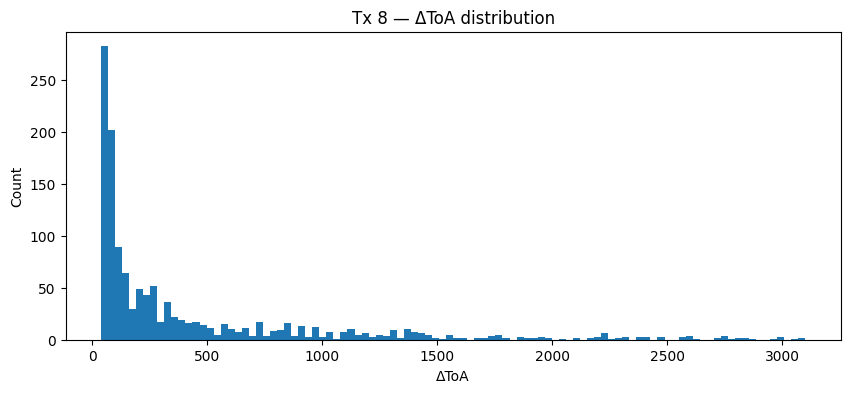

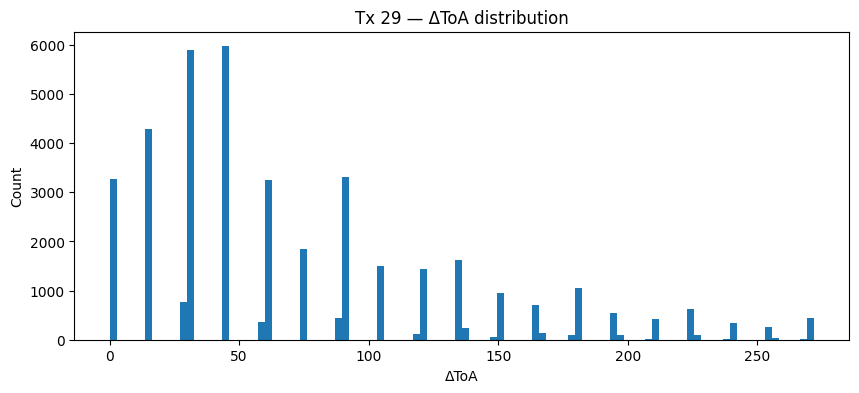

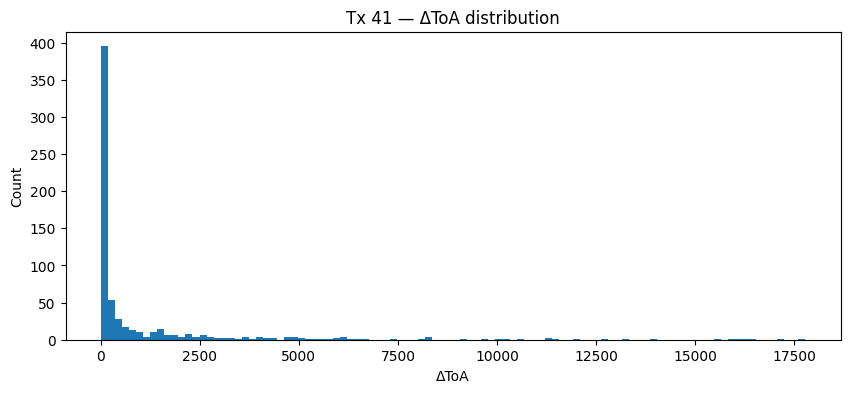

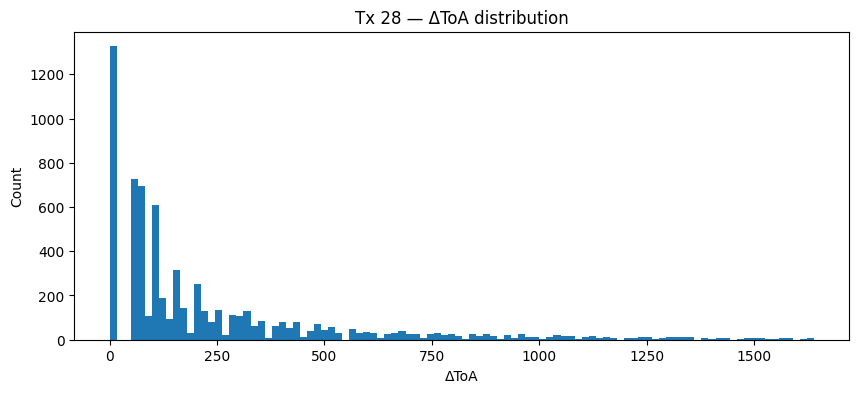

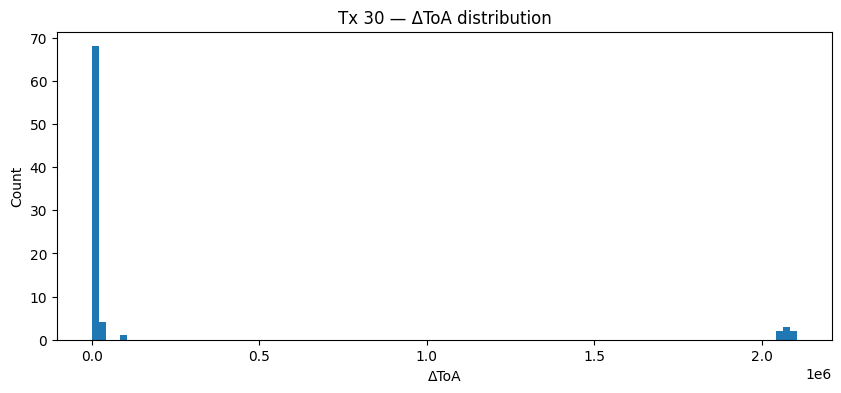

In [25]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(file_path, "r") as f:
    data = f["data"][:]
    labels = f["labels"][:, 0]

toa = data[:, 0]

for tx in [8, 29, 41, 28, 30]:

    idx = np.where(labels == tx)[0]

    tx_toa = toa[idx]
    dt = np.diff(tx_toa)

    # Remove huge inter-burst gaps for visualization
    dt_plot = dt[dt < np.percentile(dt, 95)]

    plt.figure(figsize=(10, 4))

    plt.hist(dt_plot, bins=100)

    plt.xlabel("ΔToA")
    plt.ylabel("Count")
    plt.title(f"Tx {tx} — ΔToA distribution")

    plt.show()

In [26]:
for tx in [8, 29, 41, 28, 30]:

    idx = np.where(labels == tx)[0]

    dt = np.diff(toa[idx])

    # Focus on the smallest 10% of intervals
    threshold = np.percentile(dt, 10)
    short_dt = dt[dt <= threshold]

    print(
        f"Tx {tx:2d} | "
        f"10th percentile={threshold:.3f} | "
        f"median(short)={np.median(short_dt):.3f} | "
        f"mean(short)={np.mean(short_dt):.3f}"
    )

Tx  8 | 10th percentile=41.150 | median(short)=40.000 | mean(short)=39.989
Tx 29 | 10th percentile=15.000 | median(short)=14.000 | mean(short)=7.722
Tx 41 | 10th percentile=11.000 | median(short)=9.000 | mean(short)=8.817
Tx 28 | 10th percentile=0.000 | median(short)=0.000 | mean(short)=0.000
Tx 30 | 10th percentile=988.400 | median(short)=902.000 | mean(short)=883.809


In [27]:
import h5py
import numpy as np

with h5py.File(file_path, "r") as f:
    data = f["data"][:]
    labels = f["labels"][:, 0]

toa = data[:, 0]

print("=" * 90)
print("POSITIVE PER-EMITTER TEMPORAL INTERVALS")
print("=" * 90)

for tx in [8, 29, 41, 28, 30]:

    idx = np.where(labels == tx)[0]

    tx_toa = toa[idx]
    dt = np.diff(tx_toa)

    zero_count = np.sum(dt == 0)

    # IMPORTANT: remove zero intervals only for temporal-period estimation
    positive_dt = dt[dt > 0]

    print(f"\nTx {tx}")
    print("-" * 70)

    print("Pulses:", len(idx))
    print("Zero ΔToA:", zero_count)
    print("Positive ΔToA:", len(positive_dt))

    if len(positive_dt) == 0:
        continue

    print(
        f"Min       : {positive_dt.min():.3f}"
    )
    print(
        f"10th pct  : {np.percentile(positive_dt, 10):.3f}"
    )
    print(
        f"25th pct  : {np.percentile(positive_dt, 25):.3f}"
    )
    print(
        f"Median    : {np.median(positive_dt):.3f}"
    )
    print(
        f"75th pct  : {np.percentile(positive_dt, 75):.3f}"
    )
    print(
        f"90th pct  : {np.percentile(positive_dt, 90):.3f}"
    )
    print(
        f"Mean      : {positive_dt.mean():.3f}"
    )
    print(
        f"Max       : {positive_dt.max():.3f}"
    )

POSITIVE PER-EMITTER TEMPORAL INTERVALS

Tx 8
----------------------------------------------------------------------
Pulses: 1355
Zero ΔToA: 0
Positive ΔToA: 1354
Min       : 38.500
10th pct  : 41.150
25th pct  : 79.500
Median    : 199.875
75th pct  : 714.750
90th pct  : 1841.147
Mean      : 4945.923
Max       : 1915840.125

Tx 29
----------------------------------------------------------------------
Pulses: 42334
Zero ΔToA: 3079
Positive ΔToA: 39254
Min       : 0.125
10th pct  : 15.250
25th pct  : 30.000
Median    : 60.000
75th pct  : 134.000
90th pct  : 224.000
Mean      : 556.247
Max       : 1800675.000

Tx 41
----------------------------------------------------------------------
Pulses: 681
Zero ΔToA: 0
Positive ΔToA: 680
Min       : 6.750
10th pct  : 11.000
25th pct  : 27.000
Median    : 109.000
75th pct  : 991.750
90th pct  : 5425.994
Mean      : 34793.805
Max       : 4156945.000

Tx 28
----------------------------------------------------------------------
Pulses: 7177
Zero ΔToA:

In [28]:
from collections import Counter
import numpy as np

print("=" * 90)
print("DOMINANT POSITIVE ΔToA MODES")
print("=" * 90)

for tx in [8, 29, 41, 28, 30]:

    idx = np.where(labels == tx)[0]

    dt = np.diff(toa[idx])
    dt = dt[dt > 0]

    # Round to a small precision so nearly identical intervals
    # are grouped together.
    rounded = np.round(dt, 1)

    counts = Counter(rounded)

    print(f"\nTx {tx}")
    print("-" * 60)

    for interval, count in counts.most_common(20):
        print(
            f"ΔToA ≈ {interval:10.1f} : "
            f"{count:7d}"
        )

DOMINANT POSITIVE ΔToA MODES

Tx 8
------------------------------------------------------------
ΔToA ≈       80.0 :      72
ΔToA ≈       40.0 :      59
ΔToA ≈       60.0 :      56
ΔToA ≈       79.5 :      46
ΔToA ≈       80.5 :      42
ΔToA ≈      120.0 :      36
ΔToA ≈       40.5 :      36
ΔToA ≈       39.5 :      35
ΔToA ≈       60.5 :      34
ΔToA ≈       59.5 :      34
ΔToA ≈       81.0 :      20
ΔToA ≈      119.5 :      19
ΔToA ≈      120.5 :      19
ΔToA ≈      160.0 :      19
ΔToA ≈      200.0 :      16
ΔToA ≈      160.5 :      14
ΔToA ≈      240.5 :      12
ΔToA ≈      240.0 :      12
ΔToA ≈      180.0 :      12
ΔToA ≈      280.0 :      12

Tx 29
------------------------------------------------------------
ΔToA ≈       30.0 :    5115
ΔToA ≈       45.0 :    3245
ΔToA ≈       15.0 :    2801
ΔToA ≈       60.0 :    2770
ΔToA ≈       90.0 :    2717
ΔToA ≈      120.0 :    1172
ΔToA ≈       75.0 :    1058
ΔToA ≈      135.0 :     994
ΔToA ≈      105.0 :     858
ΔToA ≈      180.0 :     

In [29]:
print("=" * 90)
print("BINNED ΔToA DISTRIBUTION")
print("=" * 90)

for tx in [8, 29, 41, 28, 30]:

    idx = np.where(labels == tx)[0]

    dt = np.diff(toa[idx])
    dt = dt[dt > 0]

    # Focus on the lower 95% to avoid enormous burst gaps
    cutoff = np.percentile(dt, 95)
    short = dt[dt <= cutoff]

    # 10-unit bins
    bin_width = 10

    bins = np.floor(short / bin_width) * bin_width
    counts = Counter(bins)

    print(f"\nTx {tx}")
    print("-" * 60)

    for interval, count in counts.most_common(15):
        print(
            f"{interval:8.0f}–{interval+bin_width:8.0f} : "
            f"{count:7d}"
        )

BINNED ΔToA DISTRIBUTION

Tx 8
------------------------------------------------------------
      80–      90 :     139
      40–      50 :      99
      60–      70 :      98
     120–     130 :      60
      70–      80 :      60
      50–      60 :      47
     160–     170 :      40
      30–      40 :      38
     240–     250 :      25
     110–     120 :      21
     200–     210 :      21
     180–     190 :      20
     230–     240 :      18
     280–     290 :      18
     320–     330 :      16

Tx 29
------------------------------------------------------------
      40–      50 :    5969
      30–      40 :    5896
      10–      20 :    4282
      90–     100 :    3226
      60–      70 :    3159
     130–     140 :    1855
      70–      80 :    1837
     100–     110 :    1495
     120–     130 :    1361
     180–     190 :     989
     150–     160 :     903
     160–     170 :     827
      20–      30 :     774
     220–     230 :     729
     190–     200 :     645


In [31]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Your existing file path
file_path = "/content/scan/train_scan/config_0.h5"

with h5py.File(file_path, "r") as f:

    data = f["data"][:]
    labels = f["labels"][:, 0]

    feature_names = [
        x.decode("utf-8") if isinstance(x, bytes) else str(x)
        for x in f["metadata/feature_names"][:]
    ]

print("=" * 80)
print("TSRD DATA LOADED")
print("=" * 80)

print("Data shape   :", data.shape)
print("Labels shape :", labels.shape)
print("Features     :", feature_names)
print("Unique emitters:", len(np.unique(labels)))
print("ToA sorted   :", np.all(np.diff(data[:, 0]) >= 0))

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/scan/train_scan/config_0.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [32]:
import os

print("Current /content contents:")
print(os.listdir("/content"))

Current /content contents:
['.config', 'sample_data']


In [33]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".h5"):
            print(os.path.join(root, file))

In [34]:
import os

# Check whether any HDF5 file exists anywhere in /content
h5_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".h5"):
            h5_files.append(os.path.join(root, file))

print("H5 files found:")
for f in h5_files:
    print(f)

if not h5_files:
    print("\n❌ No HDF5 dataset found.")

H5 files found:

❌ No HDF5 dataset found.


In [56]:
import h5py
import numpy as np

file_path = "/content/tsrd_data/scan/train_scan/config_0.h5"

with h5py.File(file_path, "r") as f:

    print("HDF5 VALIDATION")
    print("=" * 60)

    print("Top-level keys:")
    for key in f.keys():
        print(" ", key)

    data = f["data"][:]
    labels = f["labels"][:, 0]

    feature_names = [
        x.decode("utf-8") if isinstance(x, bytes) else str(x)
        for x in f["metadata/feature_names"][:]
    ]

    print("\nData:")
    print("Shape       :", data.shape)
    print("Dtype       :", data.dtype)

    print("\nLabels:")
    print("Shape       :", labels.shape)
    print("Dtype       :", labels.dtype)

    print("\nFeatures:")
    print(feature_names)

    print("\nUnique emitters:")
    print(len(np.unique(labels)))

    print("\nToA ordering:")
    delta_toa = np.diff(data[:, 0])

    print("Negative ΔToA :", np.sum(delta_toa < 0))
    print("Zero ΔToA     :", np.sum(delta_toa == 0))
    print("Positive ΔToA :", np.sum(delta_toa > 0))

    print("\nFeature ranges:")

    for i, name in enumerate(feature_names):
        print(
            f"{name:15s}: "
            f"{data[:, i].min():.4f} → "
            f"{data[:, i].max():.4f}"
        )

HDF5 VALIDATION
Top-level keys:
  data
  labels
  metadata

Data:
Shape       : (169617, 5)
Dtype       : float32

Labels:
Shape       : (169617,)
Dtype       : int8

Features:
['ToA', 'Frequency', 'PulseWidth', 'AoA', 'Amplitude']

Unique emitters:
72

ToA ordering:
Negative ΔToA : 0
Zero ΔToA     : 13242
Positive ΔToA : 156374

Feature ranges:
ToA            : 200142.5312 → 29195164.0000
Frequency      : 10.3648 → 10999.5732
PulseWidth     : 0.0069 → 346.2702
AoA            : -179.9942 → 179.9866
Amplitude      : -170.4788 → -1.2513


In [57]:
from huggingface_hub import hf_hub_download
import os
import shutil

os.makedirs("/content/scan/train_scan", exist_ok=True)

print("Downloading raw config_0.h5...")

cache_path = hf_hub_download(
    repo_id="alan-turing-institute/turing-synthetic-radar-dataset",
    repo_type="dataset",
    filename="scan/train_scan/config_0.h5"
)

print("\nHugging Face cache path:")
print(cache_path)

file_path = "/content/scan/train_scan/config_0.h5"

shutil.copy2(cache_path, file_path)

print("\nCopied to:")
print(file_path)

print(
    "File size:",
    f"{os.path.getsize(file_path) / (1024**2):.2f} MiB"
)



Hugging Face cache path:
/root/.cache/huggingface/hub/datasets--alan-turing-institute--turing-synthetic-radar-dataset/snapshots/68a07b0e0189c5b4ec748c4b66dedfe26f8f1c51/scan/train_scan/config_0.h5

Copied to:
/content/scan/train_scan/config_0.h5
File size: 3.46 MiB


In [58]:
import h5py
import os

file_path = "/content/scan/train_scan/config_0.h5"

print("Exists:", os.path.exists(file_path))

with h5py.File(file_path, "r") as f:
    print("HDF5 opened successfully")
    print("Top-level keys:", list(f.keys()))
    print("Data shape:", f["data"].shape)
    print("Labels shape:", f["labels"].shape)
    print("Feature names:", [
        x.decode() if isinstance(x, bytes) else str(x)
        for x in f["metadata/feature_names"][:]
    ])

Exists: True
HDF5 opened successfully
Top-level keys: ['data', 'labels', 'metadata']
Data shape: (169617, 5)
Labels shape: (169617, 1)
Feature names: ['ToA', 'Frequency', 'PulseWidth', 'AoA', 'Amplitude']


In [59]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/content/scan/train_scan/config_0.h5"

with h5py.File(file_path, "r") as f:
    data = f["data"][:]
    labels = f["labels"][:, 0]

    feature_names = [
        x.decode("utf-8") if isinstance(x, bytes) else str(x)
        for x in f["metadata/feature_names"][:]
    ]

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)
print("Features:", feature_names)
print("Unique emitters:", len(np.unique(labels)))
print("ToA globally non-decreasing:", np.all(np.diff(data[:, 0]) >= 0))

Data shape: (169617, 5)
Labels shape: (169617,)
Features: ['ToA', 'Frequency', 'PulseWidth', 'AoA', 'Amplitude']
Unique emitters: 72
ToA globally non-decreasing: True


In [60]:
tracks = {}

for tx in np.unique(labels):
    idx = np.where(labels == tx)[0]
    tracks[int(tx)] = data[idx]

print("Number of tracks:", len(tracks))

print("\nTrack sizes:")
for tx in sorted(tracks):
    print(f"Tx {tx:2d}: {len(tracks[tx]):6d} pulses")

Number of tracks: 72

Track sizes:
Tx  0:    173 pulses
Tx  1:    302 pulses
Tx  2:    291 pulses
Tx  3:    325 pulses
Tx  4:   2883 pulses
Tx  5:   1071 pulses
Tx  7:     11 pulses
Tx  8:   1355 pulses
Tx  9:   5561 pulses
Tx 10:    132 pulses
Tx 12:     26 pulses
Tx 13:   1819 pulses
Tx 14:    176 pulses
Tx 15:      2 pulses
Tx 16:   1351 pulses
Tx 17:     25 pulses
Tx 18:   1200 pulses
Tx 19:   7701 pulses
Tx 20:   3908 pulses
Tx 21:      6 pulses
Tx 22:     75 pulses
Tx 23:     49 pulses
Tx 26:    437 pulses
Tx 28:   7177 pulses
Tx 29:  42334 pulses
Tx 30:     86 pulses
Tx 31:   2896 pulses
Tx 32:   1610 pulses
Tx 33:    221 pulses
Tx 34:    287 pulses
Tx 36:      2 pulses
Tx 39:    751 pulses
Tx 40:  13916 pulses
Tx 41:    681 pulses
Tx 42:    188 pulses
Tx 44:    410 pulses
Tx 47:      1 pulses
Tx 49:    202 pulses
Tx 50:    136 pulses
Tx 51:      3 pulses
Tx 52:    769 pulses
Tx 53:    178 pulses
Tx 55:    152 pulses
Tx 57:   2175 pulses
Tx 58:   3366 pulses
Tx 59:    194 pulses

In [62]:
bad_tracks = []

for tx, track in tracks.items():
    toa = track[:, 0]

    if not np.all(np.diff(toa) >= 0):
        bad_tracks.append(tx)

print("Tracks with invalid ToA ordering:", bad_tracks)

if len(bad_tracks) == 0:
    print("✓ All emitter tracks preserve chronological ToA ordering.")

Tracks with invalid ToA ordering: []
✓ All emitter tracks preserve chronological ToA ordering.


In [61]:
def build_temporal_features(track):
    toa = track[:, 0]
    frequency = track[:, 1]
    pulse_width = track[:, 2]
    aoa = track[:, 3]
    amplitude = track[:, 4]

    # Time difference from previous pulse
    delta_toa = np.diff(toa, prepend=toa[0])
    delta_toa[0] = 0.0

    # Explicitly identify simultaneous observations
    zero_delta_flag = (delta_toa == 0).astype(np.float32)

    # Log transform because ΔToA has a very large dynamic range
    log_delta_toa = np.log1p(delta_toa)

    features = np.column_stack([
        log_delta_toa,
        frequency,
        pulse_width,
        aoa,
        amplitude,
        zero_delta_flag
    ])

    return features.astype(np.float32)


track_features = {}

for tx, track in tracks.items():
    track_features[tx] = build_temporal_features(track)

print("Temporal feature construction complete.")
print("Number of tracks:", len(track_features))

for tx in sorted(track_features)[:5]:
    print(
        f"Tx {tx}: "
        f"shape={track_features[tx].shape}"
    )

Temporal feature construction complete.
Number of tracks: 72
Tx 0: shape=(173, 6)
Tx 1: shape=(302, 6)
Tx 2: shape=(291, 6)
Tx 3: shape=(325, 6)
Tx 4: shape=(2883, 6)


In [63]:
tx = 29

print("Feature names:")
print([
    "log_delta_toa",
    "frequency",
    "pulse_width",
    "aoa",
    "amplitude",
    "zero_delta_flag"
])

print("\nFirst 20 feature vectors:")
print(track_features[tx][:20])

Feature names:
['log_delta_toa', 'frequency', 'pulse_width', 'aoa', 'amplitude', 'zero_delta_flag']

First 20 feature vectors:
[[ 0.0000000e+00  8.5039600e+03  5.5603576e-01  4.9043049e+01
  -9.2639565e+01  1.0000000e+00]
 [ 5.2787523e+00  8.4962031e+03  5.4524827e-01  4.9248905e+01
  -9.2936531e+01  0.0000000e+00]
 [ 5.3509693e+00  8.4963623e+03  9.9354815e-01  4.9059422e+01
  -9.1788391e+01  0.0000000e+00]
 [ 3.4380114e+00  8.4947461e+03  5.4996932e-01  4.9762974e+01
  -9.1732681e+01  0.0000000e+00]
 [ 3.4420195e+00  8.4910439e+03  1.0280387e+00  4.8444832e+01
  -9.3995964e+01  0.0000000e+00]
 [ 4.5060401e+00  8.4939004e+03  5.6433666e-01  4.9320641e+01
  -9.3367210e+01  0.0000000e+00]
 [ 4.1129208e+00  8.4980371e+03  5.4485393e-01  4.9374149e+01
  -9.3813957e+01  0.0000000e+00]
 [ 4.6652064e+00  8.4976670e+03  1.0282238e+00  4.9352901e+01
  -9.3947342e+01  0.0000000e+00]
 [ 4.9117355e+00  8.4906748e+03  5.6478721e-01  4.9895252e+01
  -9.4836273e+01  0.0000000e+00]
 [ 2.7725887e+00  

In [64]:
feature_names = [
    "log_delta_toa",
    "frequency",
    "pulse_width",
    "aoa",
    "amplitude",
    "zero_delta_flag"
]

rows = []

for tx, features in track_features.items():
    for i, name in enumerate(feature_names):
        values = features[:, i]

        rows.append({
            "Emitter": tx,
            "Feature": name,
            "Min": np.min(values),
            "Max": np.max(values),
            "Mean": np.mean(values),
            "Std": np.std(values)
        })

feature_stats = pd.DataFrame(rows)

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print(feature_stats.to_string(index=False))

 Emitter         Feature       Min        Max      Mean      Std
       0   log_delta_toa    0.0000    14.5450    8.6954   1.7571
       0       frequency 1289.6949  1291.9030 1290.7390   0.3688
       0     pulse_width   91.6096   109.0720  100.1108   2.9376
       0             aoa -178.7452  -173.4911 -175.8571   1.0367
       0       amplitude -105.2424   -73.8175  -87.2549   6.1793
       0 zero_delta_flag    0.0000     1.0000    0.0058   0.0758
       1   log_delta_toa    0.0000    14.5936    7.0152   2.3834
       1       frequency 3097.9871  3352.1357 3229.2710  73.8446
       1     pulse_width    0.4720     2.1312    1.1633   0.6253
       1             aoa   55.0281    65.9800   59.6860   1.7837
       1       amplitude -144.7408   -71.1038  -98.2161  16.0189
       1 zero_delta_flag    0.0000     1.0000    0.0033   0.0574
       2   log_delta_toa    0.0000    14.4713    7.3062   1.3758
       2       frequency 2895.4009  3303.5825 3114.3811 146.7073
       2     pulse_width 

In [65]:
all_features = np.vstack(list(track_features.values()))

global_stats = pd.DataFrame({
    "Feature": feature_names,
    "Min": np.min(all_features, axis=0),
    "Max": np.max(all_features, axis=0),
    "Mean": np.mean(all_features, axis=0),
    "Std": np.std(all_features, axis=0)
})

print(global_stats.to_string(index=False))

        Feature       Min        Max      Mean       Std
  log_delta_toa    0.0000    16.3775    4.3411    1.9436
      frequency   10.3648 10999.5732 5392.6338 3144.8037
    pulse_width    0.0069   346.2702    7.8498   29.9556
            aoa -179.9942   179.9866   18.2952   84.4387
      amplitude -170.4788    -1.2513  -87.4526   18.3463
zero_delta_flag    0.0000     1.0000    0.0741    0.2621


In [66]:
def build_temporal_features(track):
    toa = track[:, 0]
    frequency = track[:, 1]
    pulse_width = track[:, 2]
    aoa = track[:, 3]
    amplitude = track[:, 4]

    # Time since previous pulse
    delta_toa = np.diff(toa, prepend=toa[0])
    delta_toa[0] = 0.0

    # Explicit simultaneous-PDW indicator
    zero_delta_flag = (delta_toa == 0).astype(np.float32)

    # Compress highly skewed temporal gaps
    log_delta_toa = np.log1p(delta_toa)

    # Circular encoding for AoA
    aoa_rad = np.deg2rad(aoa)
    sin_aoa = np.sin(aoa_rad)
    cos_aoa = np.cos(aoa_rad)

    features = np.column_stack([
        log_delta_toa,
        frequency,
        pulse_width,
        sin_aoa,
        cos_aoa,
        amplitude,
        zero_delta_flag
    ])

    return features.astype(np.float32)


track_features = {}

for tx, track in tracks.items():
    track_features[tx] = build_temporal_features(track)

feature_names = [
    "log_delta_toa",
    "frequency",
    "pulse_width",
    "sin_aoa",
    "cos_aoa",
    "amplitude",
    "zero_delta_flag"
]

print("Features:", feature_names)

for tx in [8, 29, 41]:
    print(f"Tx {tx}: {track_features[tx].shape}")

Features: ['log_delta_toa', 'frequency', 'pulse_width', 'sin_aoa', 'cos_aoa', 'amplitude', 'zero_delta_flag']
Tx 8: (1355, 7)
Tx 29: (42334, 7)
Tx 41: (681, 7)


In [67]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

train_tracks = {}
val_tracks = {}
test_tracks = {}

for tx, features in track_features.items():

    n = len(features)

    # Need enough observations for all three splits
    if n < 30:
        continue

    train_end = int(n * TRAIN_RATIO)
    val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    train_tracks[tx] = features[:train_end]
    val_tracks[tx] = features[train_end:val_end]
    test_tracks[tx] = features[val_end:]

print("Emitters included:", len(train_tracks))

print("\nSplit sizes:")
for tx in sorted(train_tracks):
    print(
        f"Tx {tx:2d}: "
        f"train={len(train_tracks[tx]):6d}, "
        f"val={len(val_tracks[tx]):5d}, "
        f"test={len(test_tracks[tx]):5d}"
    )


Emitters included: 62

Split sizes:
Tx  0: train=   121, val=   26, test=   26
Tx  1: train=   211, val=   45, test=   46
Tx  2: train=   203, val=   44, test=   44
Tx  3: train=   227, val=   49, test=   49
Tx  4: train=  2018, val=  432, test=  433
Tx  5: train=   749, val=  161, test=  161
Tx  8: train=   948, val=  203, test=  204
Tx  9: train=  3892, val=  834, test=  835
Tx 10: train=    92, val=   20, test=   20
Tx 13: train=  1273, val=  273, test=  273
Tx 14: train=   123, val=   26, test=   27
Tx 16: train=   945, val=  203, test=  203
Tx 18: train=   840, val=  180, test=  180
Tx 19: train=  5390, val= 1155, test= 1156
Tx 20: train=  2735, val=  586, test=  587
Tx 22: train=    52, val=   11, test=   12
Tx 23: train=    34, val=    7, test=    8
Tx 26: train=   305, val=   66, test=   66
Tx 28: train=  5023, val= 1077, test= 1077
Tx 29: train= 29633, val= 6350, test= 6351
Tx 30: train=    60, val=   13, test=   13
Tx 31: train=  2027, val=  434, test=  435
Tx 32: train=  112

In [68]:
bad_splits = []

for tx in train_tracks:

    original = track_features[tx]

    n = len(original)
    train_end = int(n * TRAIN_RATIO)
    val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    train_part = original[:train_end]
    val_part = original[train_end:val_end]
    test_part = original[val_end:]

    # Check that observations weren't accidentally reordered
    if len(train_part) > 1 and len(val_part) > 0:
        if not np.array_equal(train_part, original[:train_end]):
            bad_splits.append(tx)

print("Invalid splits:", bad_splits)

if not bad_splits:
    print("✓ Chronological train/validation/test split verified.")

Invalid splits: []
✓ Chronological train/validation/test split verified.


In [69]:
from sklearn.preprocessing import StandardScaler

# Continuous features: columns 0–5
continuous_cols = [
    "log_delta_toa",
    "frequency",
    "pulse_width",
    "sin_aoa",
    "cos_aoa",
    "amplitude"
]

binary_col = "zero_delta_flag"

# --------------------------------------------------
# 1. Collect ALL training observations
# --------------------------------------------------

X_train_all = np.vstack([
    train_tracks[tx]
    for tx in train_tracks
])

print("Training observations:", X_train_all.shape)

# --------------------------------------------------
# 2. Fit scaler ONLY on training data
# --------------------------------------------------

scaler = StandardScaler()

scaler.fit(X_train_all[:, :6])

print("\nScaler fitted on training data only.")

print("\nTraining means:")
for name, value in zip(continuous_cols, scaler.mean_):
    print(f"{name:16s}: {value:.6f}")

print("\nTraining standard deviations:")
for name, value in zip(continuous_cols, scaler.scale_):
    print(f"{name:16s}: {value:.6f}")

# --------------------------------------------------
# 3. Transform train / validation / test
# --------------------------------------------------

scaled_train_tracks = {}
scaled_val_tracks = {}
scaled_test_tracks = {}

def scale_track(track):
    scaled = track.copy()

    # Scale continuous features
    scaled[:, :6] = scaler.transform(track[:, :6])

    # Keep binary flag unchanged
    scaled[:, 6] = track[:, 6]

    return scaled.astype(np.float32)

for tx in train_tracks:
    scaled_train_tracks[tx] = scale_track(train_tracks[tx])
    scaled_val_tracks[tx] = scale_track(val_tracks[tx])
    scaled_test_tracks[tx] = scale_track(test_tracks[tx])

print("\n✓ Scaling completed.")

Training observations: (118642, 7)

Scaler fitted on training data only.

Training means:
log_delta_toa   : 4.254297
frequency       : 5383.167834
pulse_width     : 7.858290
sin_aoa         : 0.323852
cos_aoa         : 0.274025
amplitude       : -86.444398

Training standard deviations:
log_delta_toa   : 1.966793
frequency       : 3139.795931
pulse_width     : 29.929301
sin_aoa         : 0.621385
cos_aoa         : 0.658718
amplitude       : 18.654135

✓ Scaling completed.


In [70]:
# Verify that the training continuous features
# are approximately zero mean and unit variance.

scaled_train_all = np.vstack([
    scaled_train_tracks[tx]
    for tx in scaled_train_tracks
])

print("Scaled training means:")
print(np.mean(scaled_train_all[:, :6], axis=0))

print("\nScaled training standard deviations:")
print(np.std(scaled_train_all[:, :6], axis=0))

print("\nBinary flag values:")
print(np.unique(scaled_train_all[:, 6]))

print("\n✓ Scaler verification complete.")

Scaled training means:
[ 6.8308786e-06 -2.3412916e-07  2.9308924e-06 -2.1353817e-07
 -5.1433358e-07 -2.4695419e-07]

Scaled training standard deviations:
[0.9999581  0.99996036 0.99997324 0.9999966  0.9999341  0.99999315]

Binary flag values:
[0. 1.]

✓ Scaler verification complete.


In [71]:
id="build_gru_sequences"
WINDOW_SIZE = 32

def create_sequences(track_dict, window_size=32):
    X = []
    y = []
    sequence_emitters = []

    for tx, track in track_dict.items():

        n = len(track)

        # Need at least window + target
        if n <= window_size:
            continue

        for i in range(n - window_size):

            # Previous 32 PDWs
            X.append(track[i:i + window_size])

            # Next PDW
            y.append(track[i + window_size])

            # Keep emitter ID for later analysis
            sequence_emitters.append(tx)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    sequence_emitters = np.asarray(sequence_emitters)

    return X, y, sequence_emitters


X_train, y_train, tx_train = create_sequences(
    scaled_train_tracks,
    WINDOW_SIZE
)

X_val, y_val, tx_val = create_sequences(
    scaled_val_tracks,
    WINDOW_SIZE
)

X_test, y_test, tx_test = create_sequences(
    scaled_test_tracks,
    WINDOW_SIZE
)

print("GRU sequence shapes")
print("-------------------")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)

print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

GRU sequence shapes
-------------------
X_train: (116667, 32, 7)
y_train: (116667, 7)
X_val:   (23646, 32, 7)
y_val:   (23646, 7)
X_test:  (23673, 32, 7)
y_test:  (23673, 7)


In [72]:
id="verify_gru_sequences"

print("Expected input dimensions:")
print("Samples × Timesteps × Features")
print()

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nTarget dimensions:")
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

print("\nUnique emitters represented:")
print("Train:", len(np.unique(tx_train)))
print("Val:  ", len(np.unique(tx_val)))
print("Test: ", len(np.unique(tx_test)))

print("\n✓ Sequence construction complete.")

Expected input dimensions:
Samples × Timesteps × Features

X_train: (116667, 32, 7)
X_val:   (23646, 32, 7)
X_test:  (23673, 32, 7)

Target dimensions:
y_train: (116667, 7)
y_val:   (23646, 7)
y_test:  (23673, 7)

Unique emitters represented:
Train: 60
Val:   44
Test:  44

✓ Sequence construction complete.


In [73]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

N_FEATURES = X_train.shape[-1]
WINDOW_SIZE = X_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE, N_FEATURES)),

    layers.GRU(
        64,
        return_sequences=False,
        name="gru_64"
    ),

    layers.Dropout(
        0.20,
        name="dropout"
    ),

    layers.Dense(
        32,
        activation="relu",
        name="dense_32"
    ),

    layers.Dense(
        N_FEATURES,
        activation="linear",
        name="next_pdw"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.Huber(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="MAE")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_64 (GRU)                    │ (None, 64)             │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_pdw (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,327 (63.78 KB)

 Trainable params: 16,327 (63.78 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),

    epochs=30,
    batch_size=256,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - MAE: 0.2278 - loss: 0.0710 - val_MAE: 0.1383 - val_loss: 0.0394 - learning_rate: 0.0010
Epoch 2/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - MAE: 0.1721 - loss: 0.0460 - val_MAE: 0.1286 - val_loss: 0.0372 - learning_rate: 0.0010
Epoch 3/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - MAE: 0.1622 - loss: 0.0431 - val_MAE: 0.1256 - val_loss: 0.0362 - learning_rate: 0.0010
Epoch 4/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - MAE: 0.1564 - loss: 0.0413 - val_MAE: 0.1246 - val_loss: 0.0362 - learning_rate: 0.0010
Epoch 5/30
453/456 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - MAE: 0.1535 - loss: 0.0405
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
456/456 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - MAE: 0.1527 - loss: 0.0402 - val_MAE: 0.1238 - val_loss: 0.0361 - learning_rate: 0.0010
Epoch 6/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - MAE: 0.1497 - loss: 0.0394 - val_MAE: 0.1217 - val_loss: 0.0357 - learning_rate: 5.0000e-

In [75]:
print("\nTraining completed.")

print("Epochs actually trained:", len(history.history["loss"]))

print("\nBest training loss:",
      min(history.history["loss"]))

print("Best validation loss:",
      min(history.history["val_loss"]))

print("\nFinal recorded epoch:")
print("Train loss:", history.history["loss"][-1])
print("Val loss:  ", history.history["val_loss"][-1])


Training completed.
Epochs actually trained: 30

Best training loss: 0.03540895879268646
Best validation loss: 0.032912008464336395

Final recorded epoch:
Train loss: 0.03544538468122482
Val loss:   0.032912008464336395


In [76]:
# Generate predictions on the untouched test set

y_pred = model.predict(
    X_test,
    batch_size=256,
    verbose=1
)

print("Prediction shape:", y_pred.shape)
print("Actual shape:    ", y_test.shape)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Prediction shape: (23673, 7)
Actual shape:     (23673, 7)


In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

feature_names = [
    "log_delta_toa",
    "frequency",
    "pulse_width",
    "sin_aoa",
    "cos_aoa",
    "amplitude",
    "zero_delta_flag"
]

print("TEST-SET FEATURE ERRORS")
print("=" * 60)

for i, name in enumerate(feature_names):

    mae = mean_absolute_error(
        y_test[:, i],
        y_pred[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test[:, i],
            y_pred[:, i]
        )
    )

    print(
        f"{name:16s} "
        f"MAE = {mae:.6f}   "
        f"RMSE = {rmse:.6f}"
    )

TEST-SET FEATURE ERRORS
log_delta_toa    MAE = 0.425125   RMSE = 0.636208
frequency        MAE = 0.040032   RMSE = 0.054170
pulse_width      MAE = 0.109756   RMSE = 0.308905
sin_aoa          MAE = 0.024909   RMSE = 0.037532
cos_aoa          MAE = 0.025764   RMSE = 0.036299
amplitude        MAE = 0.119892   RMSE = 0.183702
zero_delta_flag  MAE = 0.072798   RMSE = 0.174529


In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

feature_names = [
    "log_delta_toa",
    "frequency",
    "pulse_width",
    "sin_aoa",
    "cos_aoa",
    "amplitude",
    "zero_delta_flag"
]

print("TEST-SET FEATURE ERRORS")
print("=" * 65)

for i, name in enumerate(feature_names):

    mae = mean_absolute_error(
        y_test[:, i],
        y_pred[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test[:, i],
            y_pred[:, i]
        )
    )

    print(
        f"{name:16s} "
        f"MAE = {mae:.6f}   "
        f"RMSE = {rmse:.6f}"
    )

TEST-SET FEATURE ERRORS
log_delta_toa    MAE = 0.425125   RMSE = 0.636208
frequency        MAE = 0.040032   RMSE = 0.054170
pulse_width      MAE = 0.109756   RMSE = 0.308905
sin_aoa          MAE = 0.024909   RMSE = 0.037532
cos_aoa          MAE = 0.025764   RMSE = 0.036299
amplitude        MAE = 0.119892   RMSE = 0.183702
zero_delta_flag  MAE = 0.072798   RMSE = 0.174529


In [79]:
# --------------------------------------------------
# Recover predicted log(1 + DeltaToA)
# --------------------------------------------------

toa_mean = scaler.mean_[0]
toa_std = scaler.scale_[0]

# Inverse StandardScaler
true_log_delta = (
    y_test[:, 0] * toa_std
    + toa_mean
)

pred_log_delta = (
    y_pred[:, 0] * toa_std
    + toa_mean
)

# Inverse log1p transformation
true_delta = np.expm1(true_log_delta)
pred_delta = np.expm1(pred_log_delta)

# Numerical safety
true_delta = np.maximum(true_delta, 0)
pred_delta = np.maximum(pred_delta, 0)

# --------------------------------------------------
# Timing errors in original units
# --------------------------------------------------

abs_error = np.abs(pred_delta - true_delta)

mae_delta = np.mean(abs_error)
rmse_delta = np.sqrt(np.mean((pred_delta - true_delta) ** 2))
median_error = np.median(abs_error)
p90_error = np.percentile(abs_error, 90)
p95_error = np.percentile(abs_error, 95)

print("PHYSICAL ΔToA TEST PERFORMANCE")
print("=" * 55)

print(f"MAE:                 {mae_delta:.6f}")
print(f"RMSE:                {rmse_delta:.6f}")
print(f"Median absolute err: {median_error:.6f}")
print(f"90th percentile:     {p90_error:.6f}")
print(f"95th percentile:     {p95_error:.6f}")

print("\nTrue ΔToA statistics:")
print(f"Median:              {np.median(true_delta):.6f}")
print(f"Mean:                {np.mean(true_delta):.6f}")
print(f"Maximum:             {np.max(true_delta):.6f}")

print("\nPredicted ΔToA statistics:")
print(f"Median:              {np.median(pred_delta):.6f}")
print(f"Mean:                {np.mean(pred_delta):.6f}")
print(f"Maximum:             {np.max(pred_delta):.6f}")

PHYSICAL ΔToA TEST PERFORMANCE
MAE:                 3808.207011
RMSE:                85071.605661
Median absolute err: 48.938143
90th percentile:     505.887791
95th percentile:     1184.198854

True ΔToA statistics:
Median:              91.999995
Mean:                3938.665996
Maximum:             4156946.704563

Predicted ΔToA statistics:
Median:              85.612397
Mean:                237.756753
Maximum:             12068.414162


In [80]:
WINDOW_SIZE = 32

# --------------------------------------------------
# Statistical baseline:
# predict next DeltaToA using median of
# the previous 32 DeltaToA values
# --------------------------------------------------

stat_pred_scaled = []
stat_true_scaled = []

# We need the original scaled test tracks
for tx, track in scaled_test_tracks.items():

    if len(track) <= WINDOW_SIZE:
        continue

    for i in range(len(track) - WINDOW_SIZE):

        history = track[i:i + WINDOW_SIZE]

        # log_delta_toa is column 0
        historical_log_delta = history[:, 0]

        # Robust prediction
        predicted_log_delta = np.median(
            historical_log_delta
        )

        # Actual next value
        actual_log_delta = track[
            i + WINDOW_SIZE, 0
        ]

        stat_pred_scaled.append(
            predicted_log_delta
        )

        stat_true_scaled.append(
            actual_log_delta
        )

stat_pred_scaled = np.asarray(
    stat_pred_scaled,
    dtype=np.float32
)

stat_true_scaled = np.asarray(
    stat_true_scaled,
    dtype=np.float32
)

print("Statistical baseline samples:",
      len(stat_pred_scaled))

print("GRU test samples:",
      len(y_test))

print(
    "Same sample count:",
    len(stat_pred_scaled) == len(y_test)
)

Statistical baseline samples: 23673
GRU test samples: 23673
Same sample count: True


In [81]:
# Calculate statistical baseline errors

stat_mae = mean_absolute_error(
    stat_true_scaled,
    stat_pred_scaled
)

stat_rmse = np.sqrt(
    mean_squared_error(
        stat_true_scaled,
        stat_pred_scaled
    )
)

gru_mae = mean_absolute_error(
    y_test[:, 0],
    y_pred[:, 0]
)

gru_rmse = np.sqrt(
    mean_squared_error(
        y_test[:, 0],
        y_pred[:, 0]
    )
)

print("TIMING BASELINE COMPARISON")
print("=" * 55)

print(f"Statistical MAE:  {stat_mae:.6f}")
print(f"Statistical RMSE: {stat_rmse:.6f}")

print()

print(f"GRU MAE:          {gru_mae:.6f}")
print(f"GRU RMSE:         {gru_rmse:.6f}")

print()

print("Relative improvement of GRU:")

mae_improvement = (
    (stat_mae - gru_mae) / stat_mae
) * 100

rmse_improvement = (
    (stat_rmse - gru_rmse) / stat_rmse
) * 100

print(f"MAE:  {mae_improvement:.2f}%")
print(f"RMSE: {rmse_improvement:.2f}%")

TIMING BASELINE COMPARISON
Statistical MAE:  0.459292
Statistical RMSE: 0.717426

GRU MAE:          0.425125
GRU RMSE:         0.636208

Relative improvement of GRU:
MAE:  7.44%
RMSE: 11.32%


In [82]:
# --------------------------------------------------
# Convert statistical and GRU predictions
# back to physical DeltaToA
# --------------------------------------------------

toa_mean = scaler.mean_[0]
toa_std = scaler.scale_[0]

# Actual
true_log_delta = (
    y_test[:, 0] * toa_std
    + toa_mean
)

# GRU
gru_log_delta = (
    y_pred[:, 0] * toa_std
    + toa_mean
)

# Statistical
stat_log_delta = (
    stat_pred_scaled * toa_std
    + toa_mean
)

# Inverse log1p
true_delta = np.maximum(
    np.expm1(true_log_delta), 0
)

gru_delta = np.maximum(
    np.expm1(gru_log_delta), 0
)

stat_delta = np.maximum(
    np.expm1(stat_log_delta), 0
)

# Errors
gru_abs_error = np.abs(
    gru_delta - true_delta
)

stat_abs_error = np.abs(
    stat_delta - true_delta
)

print("PHYSICAL ΔToA COMPARISON")
print("=" * 65)

print("\nGRU:")
print(f"MAE:                 {np.mean(gru_abs_error):.6f}")
print(f"Median absolute err: {np.median(gru_abs_error):.6f}")
print(f"90th percentile:     {np.percentile(gru_abs_error, 90):.6f}")
print(f"95th percentile:     {np.percentile(gru_abs_error, 95):.6f}")

print("\nStatistical:")
print(f"MAE:                 {np.mean(stat_abs_error):.6f}")
print(f"Median absolute err: {np.median(stat_abs_error):.6f}")
print(f"90th percentile:     {np.percentile(stat_abs_error, 90):.6f}")
print(f"95th percentile:     {np.percentile(stat_abs_error, 95):.6f}")

PHYSICAL ΔToA COMPARISON

GRU:
MAE:                 3808.207011
Median absolute err: 48.938143
90th percentile:     505.887791
95th percentile:     1184.198854

Statistical:
MAE:                 3832.345241
Median absolute err: 52.340698
90th percentile:     530.284693
95th percentile:     1301.085209


In [83]:
regime_stats = []

for tx, track in train_tracks.items():

    # Recover log(1 + DeltaToA)
    log_delta = track[:, 0]

    # Undo normalization
    raw_log_delta = (
        log_delta * toa_std
        + toa_mean
    )

    # Undo log1p
    delta = np.maximum(
        np.expm1(raw_log_delta),
        0
    )

    # Ignore the first artificial zero
    delta = delta[1:]

    mean_delta = np.mean(delta)
    std_delta = np.std(delta)
    median_delta = np.median(delta)

    # Avoid division by zero
    cv = (
        std_delta / mean_delta
        if mean_delta > 0
        else np.nan
    )

    zero_fraction = np.mean(delta == 0)

    regime_stats.append({
        "tx": tx,
        "n": len(delta),
        "mean_delta": mean_delta,
        "median_delta": median_delta,
        "std_delta": std_delta,
        "cv": cv,
        "zero_fraction": zero_fraction
    })

regime_df = pd.DataFrame(regime_stats)

regime_df = regime_df.sort_values(
    "cv"
).reset_index(drop=True)

print("Emitter timing regimes")
print("=" * 80)

print(
    regime_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

Emitter timing regimes
 tx     n          mean_delta     median_delta            std_delta      cv  zero_fraction
 10    91      124447500.5405   124749550.3317         1787931.2677  0.0144         0.0000
 23    33     3937129337.7565  1758816827.7540      4787230945.0872  1.2159         0.0000
  9  3891         391220.6740          69.4073          792559.0226  2.0259         0.0000
 64    24 89120550799834.5625  2536710411.0811 215295600941548.3750  2.4158         0.0000
 30    59 25982664842214.7227  2425671776.0566  65618349725683.1328  2.5255         0.0000
 22    51 39617712548841.1406 12735645113.0183 120912158599583.4219  3.0520         0.0000
 32  1126        1263822.0529      616172.8829         4388658.5267  3.4725         0.0000
 86    99 13137363180035.7246   486368607.9855  47621586706895.8906  3.6249         0.0000
 68   107 12082071092633.1914   857415797.5838  45651007277288.0391  3.7784         0.0000
 39   524        4530964.6723      616172.8829        18611853.2163

In [84]:
regime_stats = []

for tx, track in scaled_train_tracks.items():

    # Column 0 is standardized log(1 + DeltaToA)
    scaled_log_delta = track[:, 0]

    # Undo StandardScaler
    raw_log_delta = (
        scaled_log_delta * scaler.scale_[0]
        + scaler.mean_[0]
    )

    # Undo log1p
    delta = np.maximum(
        np.expm1(raw_log_delta),
        0
    )

    # Remove only the first artificial delta
    delta = delta[1:]

    mean_delta = np.mean(delta)
    std_delta = np.std(delta)
    median_delta = np.median(delta)

    cv = (
        std_delta / mean_delta
        if mean_delta > 0
        else np.nan
    )

    # Actual zero-interval fraction
    zero_fraction = np.mean(delta == 0)

    regime_stats.append({
        "tx": tx,
        "n": len(delta),
        "mean_delta": mean_delta,
        "median_delta": median_delta,
        "std_delta": std_delta,
        "cv": cv,
        "zero_fraction": zero_fraction
    })

regime_df = pd.DataFrame(regime_stats)

regime_df = regime_df.sort_values(
    "cv"
).reset_index(drop=True)

print("CORRECTED EMITTER TIMING REGIMES")
print("=" * 90)

print(
    regime_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

CORRECTED EMITTER TIMING REGIMES
 tx     n  mean_delta  median_delta    std_delta      cv  zero_fraction
 10    91   1500.1098     1502.0000      10.9720  0.0073         0.0000
 32  1126    122.8242      100.0000      78.6630  0.6405         0.0000
 23    33   6719.6988     5770.0020    5597.3527  0.8330         0.0000
 39   524    186.0687      100.0000     212.0448  1.1396         0.0000
  9  3891     45.1036        0.0000      66.6291  1.4772         0.0000
 20  2734     39.8350       20.0000      77.0039  1.9331         0.0000
 64    24 629542.0443     6951.0013 1300669.7453  2.0661         0.0000
 22    51 382065.0396    15790.0011  879774.6271  2.3027         0.0000
 30    59 292680.4649     6794.7197  716056.5789  2.4465         0.0000
 41   475    337.9093       50.8750     976.9367  2.8911         0.0000
 86    99 151737.4735     3001.0010  528566.2961  3.4834         0.0000
 68   107 140915.8295     4003.9994  508160.3996  3.6061         0.0000
 63    29  85386.0196    13691.

In [85]:
print("\nLOWEST-CV EMITTERS")
print("=" * 60)

print(
    regime_df[
        ["tx", "n", "mean_delta", "median_delta",
         "std_delta", "cv", "zero_fraction"]
    ].head(10).to_string(index=False)
)

print("\nHIGHEST-CV EMITTERS")
print("=" * 60)

print(
    regime_df[
        ["tx", "n", "mean_delta", "median_delta",
         "std_delta", "cv", "zero_fraction"]
    ].tail(10).to_string(index=False)
)


LOWEST-CV EMITTERS
 tx    n  mean_delta  median_delta    std_delta     cv  zero_fraction
 10   91   1500.1098     1502.0000      10.9720 0.0073         0.0000
 32 1126    122.8242      100.0000      78.6630 0.6405         0.0000
 23   33   6719.6988     5770.0020    5597.3527 0.8330         0.0000
 39  524    186.0687      100.0000     212.0448 1.1396         0.0000
  9 3891     45.1036        0.0000      66.6291 1.4772         0.0000
 20 2734     39.8350       20.0000      77.0039 1.9331         0.0000
 64   24 629542.0443     6951.0013 1300669.7453 2.0661         0.0000
 22   51 382065.0396    15790.0011  879774.6271 2.3027         0.0000
 30   59 292680.4649     6794.7197  716056.5789 2.4465         0.0000
 41  475    337.9093       50.8750     976.9367 2.8911         0.0000

HIGHEST-CV EMITTERS
 tx     n  mean_delta  median_delta  std_delta      cv  zero_fraction
 80  3957   3322.0822      200.0000 73984.5758 22.2705         0.0000
 28  5022   3459.9610      100.0000 77934.7920 22

In [86]:
regime_stats = []

for tx, track in scaled_train_tracks.items():

    # ---------------------------------------------
    # Recover physical DeltaToA
    # ---------------------------------------------

    scaled_log_delta = track[:, 0]

    raw_log_delta = (
        scaled_log_delta * scaler.scale_[0]
        + scaler.mean_[0]
    )

    delta = np.maximum(
        np.expm1(raw_log_delta),
        0
    )

    # Remove first artificial delta
    delta_for_stats = delta[1:]

    # ---------------------------------------------
    # Use original binary feature for zero events
    # ---------------------------------------------

    zero_flags = track[1:, 6]

    mean_delta = np.mean(delta_for_stats)
    std_delta = np.std(delta_for_stats)
    median_delta = np.median(delta_for_stats)

    cv = (
        std_delta / mean_delta
        if mean_delta > 0
        else np.nan
    )

    zero_fraction = np.mean(zero_flags)

    # Robust variability
    mad = np.median(
        np.abs(delta_for_stats - median_delta)
    )

    robust_cv = (
        mad / median_delta
        if median_delta > 0
        else np.nan
    )

    regime_stats.append({
        "tx": tx,
        "n": len(delta_for_stats),
        "mean_delta": mean_delta,
        "median_delta": median_delta,
        "std_delta": std_delta,
        "cv": cv,
        "mad": mad,
        "robust_cv": robust_cv,
        "zero_fraction": zero_fraction
    })

regime_df = pd.DataFrame(regime_stats)

regime_df = regime_df.sort_values(
    "robust_cv"
).reset_index(drop=True)

print("FINAL TIMING REGIME TABLE")
print("=" * 105)

print(
    regime_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

FINAL TIMING REGIME TABLE
 tx     n  mean_delta  median_delta    std_delta      cv        mad  robust_cv  zero_fraction
  9  3891     45.1036        0.0000      66.6291  1.4772     0.0000     0.0000         0.6518
 19  5389   1189.0895       20.0000   48355.9381 40.6664     0.0000     0.0000         0.0000
 39   524    186.0687      100.0000     212.0448  1.1396     0.0000     0.0000         0.0000
 32  1126    122.8242      100.0000      78.6630  0.6405     0.0000     0.0000         0.0000
 18   839  10273.5392      500.0000  141210.1282 13.7450     2.0001     0.0040         0.0000
 10    91   1500.1098     1502.0000      10.9720  0.0073     8.0001     0.0053         0.0000
 76   762  17033.4543     1502.0000  172359.3681 10.1189     8.2503     0.0055         0.0000
 49   140 107785.7356     2017.5004  449733.6212  4.1725    33.5003     0.0166         0.0000
 65  4877    466.6412       24.0000   28635.3816 61.3649     0.5000     0.0208         0.0000
 77   111  78379.0664     1120.000

In [87]:
# --------------------------------------------------
# Per-emitter physical timing comparison
# --------------------------------------------------

comparison_rows = []

for tx in np.unique(tx_test):

    mask = (tx_test == tx)

    # Actual physical DeltaToA
    actual_log = (
        y_test[mask, 0] * scaler.scale_[0]
        + scaler.mean_[0]
    )

    # GRU prediction
    gru_log = (
        y_pred[mask, 0] * scaler.scale_[0]
        + scaler.mean_[0]
    )

    # Statistical prediction
    stat_log = (
        stat_pred_scaled[mask] * scaler.scale_[0]
        + scaler.mean_[0]
    )

    actual = np.maximum(np.expm1(actual_log), 0)
    gru = np.maximum(np.expm1(gru_log), 0)
    stat = np.maximum(np.expm1(stat_log), 0)

    gru_error = np.abs(gru - actual)
    stat_error = np.abs(stat - actual)

    comparison_rows.append({
        "tx": int(tx),
        "samples": int(np.sum(mask)),

        "gru_mae": np.mean(gru_error),
        "stat_mae": np.mean(stat_error),

        "gru_median": np.median(gru_error),
        "stat_median": np.median(stat_error),

        "gru_p90": np.percentile(gru_error, 90),
        "stat_p90": np.percentile(stat_error, 90)
    })

comparison_df = pd.DataFrame(comparison_rows)

# Absolute improvement: positive means GRU is better
comparison_df["mae_improvement"] = (
    comparison_df["stat_mae"]
    - comparison_df["gru_mae"]
)

comparison_df["median_improvement"] = (
    comparison_df["stat_median"]
    - comparison_df["gru_median"]
)

comparison_df["p90_improvement"] = (
    comparison_df["stat_p90"]
    - comparison_df["gru_p90"]
)

print("PER-EMITTER TIMING PERFORMANCE")
print("=" * 110)

print(
    comparison_df.sort_values(
        "mae_improvement",
        ascending=False
    ).to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

PER-EMITTER TIMING PERFORMANCE
 tx  samples     gru_mae    stat_mae  gru_median  stat_median    gru_p90   stat_p90  mae_improvement  median_improvement  p90_improvement
 90       11 195411.8229 198643.7161  15890.0840   17630.0126 29919.4158 32581.0140        3231.8932           1739.9287        2661.5982
 41       71 148258.6863 151465.2171   1203.0440    4471.5105 13913.1140 17354.6612        3206.5308           3268.4665        3441.5472
  1       14 157672.9131 159123.2929   5797.0264    6402.6288 44903.7331 48966.7917        1450.3798            605.6024        4063.0586
 26       34  62250.2432  63254.1035    489.2141    1309.3446 12162.0731 16425.7846        1003.8603            820.1305        4263.7115
 82       16   3109.0549   3913.2833   2699.1834    2842.7436  5244.1515  8487.5014         804.2285            143.5602        3243.3499
 67       13 164649.7607 165385.5693    400.2205     283.9981  6582.9403  8241.4032         735.8085           -116.2224        1658.4628
 95

In [88]:
print("\nMODEL WIN COUNTS")
print("=" * 60)

gru_mae_wins = np.sum(
    comparison_df["mae_improvement"] > 0
)

stat_mae_wins = np.sum(
    comparison_df["mae_improvement"] < 0
)

ties = np.sum(
    comparison_df["mae_improvement"] == 0
)

print(f"Emitters where GRU has lower MAE:        {gru_mae_wins}")
print(f"Emitters where statistical has lower MAE: {stat_mae_wins}")
print(f"Ties:                                     {ties}")

print("\nMedian-error comparison:")

gru_median_wins = np.sum(
    comparison_df["median_improvement"] > 0
)

stat_median_wins = np.sum(
    comparison_df["median_improvement"] < 0
)

print(
    f"GRU wins:        {gru_median_wins}"
)

print(
    f"Statistical wins:{stat_median_wins}"
)


MODEL WIN COUNTS
Emitters where GRU has lower MAE:        29
Emitters where statistical has lower MAE: 15
Ties:                                     0

Median-error comparison:
GRU wins:        28
Statistical wins:16


In [89]:
weights = np.arange(0.0, 1.01, 0.1)

hybrid_results = []

# Physical predictions already computed:
# gru_delta
# stat_delta
# true_delta

for w in weights:

    hybrid_delta = (
        w * gru_delta
        + (1.0 - w) * stat_delta
    )

    error = np.abs(
        hybrid_delta - true_delta
    )

    hybrid_results.append({
        "weight_gru": w,
        "mae": np.mean(error),
        "median_error": np.median(error),
        "p90_error": np.percentile(error, 90),
        "p95_error": np.percentile(error, 95)
    })

hybrid_df = pd.DataFrame(hybrid_results)

print("FIXED-WEIGHT HYBRID SWEEP")
print("=" * 75)

print(
    hybrid_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

FIXED-WEIGHT HYBRID SWEEP
 weight_gru         mae  median_error  p90_error   p95_error
   0.000000 3832.345241     52.340698 530.284693 1301.085209
   0.100000 3828.580015     53.251658 526.498961 1292.873727
   0.200000 3825.204092     53.751241 520.003219 1275.971799
   0.300000 3822.152975     53.474711 515.790099 1257.679318
   0.400000 3819.288829     52.835728 513.414312 1247.069949
   0.500000 3816.649870     51.820372 504.814127 1234.535845
   0.600000 3814.271512     51.208382 500.872975 1229.068068
   0.700000 3812.172588     50.618075 502.017310 1204.633483
   0.800000 3810.441770     49.848634 506.199855 1191.734166
   0.900000 3808.998378     49.281892 504.895286 1181.575660
   1.000000 3808.207011     48.938143 505.887791 1184.198854


In [90]:
best_mae = hybrid_df.loc[
    hybrid_df["mae"].idxmin()
]

best_median = hybrid_df.loc[
    hybrid_df["median_error"].idxmin()
]

print("\nBEST BY MAE")
print("=" * 40)
print(best_mae)

print("\nBEST BY MEDIAN ERROR")
print("=" * 40)
print(best_median)


BEST BY MAE
weight_gru        1.0000
mae            3808.2070
median_error     48.9381
p90_error       505.8878
p95_error      1184.1989
Name: 10, dtype: float64

BEST BY MEDIAN ERROR
weight_gru        1.0000
mae            3808.2070
median_error     48.9381
p90_error       505.8878
p95_error      1184.1989
Name: 10, dtype: float64


In [91]:
# ============================================================
# VALIDATION GRU PREDICTIONS
# ============================================================

y_pred_val = model.predict(
    X_val,
    batch_size=256,
    verbose=1
)

print("Validation prediction shape:", y_pred_val.shape)
print("Validation target shape:", y_val.shape)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Validation prediction shape: (23646, 7)
Validation target shape: (23646, 7)


In [92]:
# ============================================================
# VALIDATION STATISTICAL BASELINE
# ============================================================

WINDOW_SIZE = 32

stat_pred_val_scaled = []
stat_true_val_scaled = []
stat_tx_val = []

for tx, track in scaled_val_tracks.items():

    if len(track) <= WINDOW_SIZE:
        continue

    for i in range(len(track) - WINDOW_SIZE):

        # Median of previous 32 log-ΔToA values
        pred = np.median(track[i:i+WINDOW_SIZE, 0])

        # Actual next log-ΔToA
        true = track[i+WINDOW_SIZE, 0]

        stat_pred_val_scaled.append(pred)
        stat_true_val_scaled.append(true)
        stat_tx_val.append(tx)

stat_pred_val_scaled = np.asarray(
    stat_pred_val_scaled, dtype=np.float32
)

stat_true_val_scaled = np.asarray(
    stat_true_val_scaled, dtype=np.float32
)

stat_tx_val = np.asarray(stat_tx_val)

print("Statistical validation predictions:", len(stat_pred_val_scaled))
print("Statistical validation targets:", len(stat_true_val_scaled))
print("GRU validation predictions:", len(y_pred_val))

print(
    "Aligned:",
    len(stat_pred_val_scaled) == len(y_pred_val)
)

Statistical validation predictions: 23646
Statistical validation targets: 23646
GRU validation predictions: 23646
Aligned: True


In [93]:
# ============================================================
# VALIDATION FIXED-WEIGHT HYBRID SWEEP
# ============================================================

# Inverse-transform validation log-ΔToA
toa_mean = scaler.mean_[0]
toa_std = scaler.scale_[0]

true_log_delta_val = (
    y_val[:, 0] * toa_std + toa_mean
)

gru_log_delta_val = (
    y_pred_val[:, 0] * toa_std + toa_mean
)

stat_log_delta_val = (
    stat_pred_val_scaled * toa_std + toa_mean
)

# Convert log(1 + ΔToA) back to physical ΔToA
true_delta_val = np.maximum(
    np.expm1(true_log_delta_val), 0
)

gru_delta_val = np.maximum(
    np.expm1(gru_log_delta_val), 0
)

stat_delta_val = np.maximum(
    np.expm1(stat_log_delta_val), 0
)

# ------------------------------------------------------------
# Sweep fixed GRU weights
# ------------------------------------------------------------

weights = np.arange(0.0, 1.01, 0.1)

validation_hybrid_results = []

for w in weights:

    hybrid_delta = (
        w * gru_delta_val
        + (1 - w) * stat_delta_val
    )

    error = np.abs(
        hybrid_delta - true_delta_val
    )

    validation_hybrid_results.append({
        "weight_gru": w,
        "mae": np.mean(error),
        "median_error": np.median(error),
        "p90_error": np.percentile(error, 90),
        "p95_error": np.percentile(error, 95)
    })

validation_hybrid_df = pd.DataFrame(
    validation_hybrid_results
)

print("=" * 75)
print("VALIDATION FIXED-WEIGHT HYBRID SWEEP")
print("=" * 75)

print(
    validation_hybrid_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

VALIDATION FIXED-WEIGHT HYBRID SWEEP
 weight_gru         mae  median_error  p90_error  p95_error
   0.000000 2744.095509     44.000002 274.000013 550.205331
   0.100000 2741.820918     43.543870 270.516070 542.850682
   0.200000 2739.722277     42.605249 267.419484 540.797775
   0.300000 2737.764244     42.348867 264.172877 538.594342
   0.400000 2735.944736     41.946791 262.494530 531.788303
   0.500000 2734.285529     41.779847 260.723854 527.239437
   0.600000 2732.826616     41.309205 259.921862 523.839546
   0.700000 2731.578582     41.178030 259.688713 523.006014
   0.800000 2730.689149     41.070845 259.846109 522.479628
   0.900000 2730.007624     40.960635 260.084225 518.069013
   1.000000 2729.700624     40.781736 260.576006 522.945809


In [94]:
# ============================================================
# SELECT VALIDATION WEIGHT
# ============================================================

best_val_mae = validation_hybrid_df.loc[
    validation_hybrid_df["mae"].idxmin()
]

best_val_median = validation_hybrid_df.loc[
    validation_hybrid_df["median_error"].idxmin()
]

best_val_p90 = validation_hybrid_df.loc[
    validation_hybrid_df["p90_error"].idxmin()
]

best_val_p95 = validation_hybrid_df.loc[
    validation_hybrid_df["p95_error"].idxmin()
]

print("\nBEST BY VALIDATION MAE")
print("=" * 40)
print(best_val_mae)

print("\nBEST BY VALIDATION MEDIAN")
print("=" * 40)
print(best_val_median)

print("\nBEST BY VALIDATION P90")
print("=" * 40)
print(best_val_p90)

print("\nBEST BY VALIDATION P95")
print("=" * 40)
print(best_val_p95)


BEST BY VALIDATION MAE
weight_gru        1.0000
mae            2729.7006
median_error     40.7817
p90_error       260.5760
p95_error       522.9458
Name: 10, dtype: float64

BEST BY VALIDATION MEDIAN
weight_gru        1.0000
mae            2729.7006
median_error     40.7817
p90_error       260.5760
p95_error       522.9458
Name: 10, dtype: float64

BEST BY VALIDATION P90
weight_gru        0.7000
mae            2731.5786
median_error     41.1780
p90_error       259.6887
p95_error       523.0060
Name: 7, dtype: float64

BEST BY VALIDATION P95
weight_gru        0.9000
mae            2730.0076
median_error     40.9606
p90_error       260.0842
p95_error       518.0690
Name: 9, dtype: float64


In [95]:
# ============================================================
# FINAL TEST EVALUATION
# Validation-selected weight is frozen at w = 1.0
# ============================================================

FINAL_WEIGHT_GRU = float(
    best_val_mae["weight_gru"]
)

print("Frozen GRU weight:", FINAL_WEIGHT_GRU)

# Test predictions already exist:
# y_pred, y_test
# gru_delta, stat_delta, true_delta

final_hybrid_delta = (
    FINAL_WEIGHT_GRU * gru_delta
    + (1 - FINAL_WEIGHT_GRU) * stat_delta
)

final_error = np.abs(
    final_hybrid_delta - true_delta
)

final_metrics = {
    "MAE": np.mean(final_error),
    "Median Error": np.median(final_error),
    "P90 Error": np.percentile(final_error, 90),
    "P95 Error": np.percentile(final_error, 95),
    "RMSE": np.sqrt(np.mean(
        (final_hybrid_delta - true_delta) ** 2
    ))
}

print("\nFINAL TEST RESULTS")
print("=" * 50)

for metric, value in final_metrics.items():
    print(f"{metric:20s}: {value:.6f}")

Frozen GRU weight: 1.0

FINAL TEST RESULTS
MAE                 : 3808.207011
Median Error        : 48.938143
P90 Error           : 505.887791
P95 Error           : 1184.198854
RMSE                : 85071.605661


In [96]:
# ============================================================
# STEP 18 — VALIDATION: GRU VS STATISTICAL WIN ANALYSIS
# ============================================================

gru_val_error = np.abs(
    gru_delta_val - true_delta_val
)

stat_val_error = np.abs(
    stat_delta_val - true_delta_val
)

gru_wins = gru_val_error < stat_val_error
stat_wins = stat_val_error < gru_val_error
ties = gru_val_error == stat_val_error

print("=" * 65)
print("VALIDATION PREDICTOR WIN ANALYSIS")
print("=" * 65)

print(f"Total samples : {len(gru_val_error):,}")

print(
    f"GRU wins      : {np.sum(gru_wins):,} "
    f"({100*np.mean(gru_wins):.2f}%)"
)

print(
    f"Stat wins     : {np.sum(stat_wins):,} "
    f"({100*np.mean(stat_wins):.2f}%)"
)

print(
    f"Ties          : {np.sum(ties):,} "
    f"({100*np.mean(ties):.2f}%)"
)

print("\nMean absolute error")
print(f"GRU           : {np.mean(gru_val_error):.6f}")
print(f"Statistical   : {np.mean(stat_val_error):.6f}")

print("\nMedian absolute error")
print(f"GRU           : {np.median(gru_val_error):.6f}")
print(f"Statistical   : {np.median(stat_val_error):.6f}")

VALIDATION PREDICTOR WIN ANALYSIS
Total samples : 23,646
GRU wins      : 11,857 (50.14%)
Stat wins     : 11,789 (49.86%)
Ties          : 0 (0.00%)

Mean absolute error
GRU           : 2729.700624
Statistical   : 2744.095509

Median absolute error
GRU           : 40.781736
Statistical   : 44.000002


In [97]:
# ============================================================
# STEP 18B — BUILD ADAPTIVE GATE FEATURES
# ============================================================

WINDOW_SIZE = 32

gate_features_val = []

# Make sure ordering matches the statistical/GRU validation samples
for tx, track in scaled_val_tracks.items():

    if len(track) <= WINDOW_SIZE:
        continue

    for i in range(len(track) - WINDOW_SIZE):

        window = track[i:i+WINDOW_SIZE]

        # ----------------------------------------------------
        # Timing statistics
        # ----------------------------------------------------

        log_dt = window[:, 0]

        timing_median = np.median(log_dt)

        timing_mad = np.median(
            np.abs(log_dt - timing_median)
        )

        timing_std = np.std(log_dt)

        # ----------------------------------------------------
        # Burst / simultaneous-event indicator
        # ----------------------------------------------------

        zero_fraction = np.mean(window[:, 6])

        # ----------------------------------------------------
        # Other PDW variability
        # ----------------------------------------------------

        frequency_std = np.std(window[:, 1])

        pulse_width_std = np.std(window[:, 2])

        # ----------------------------------------------------
        # Predictor disagreement
        # ----------------------------------------------------

        prediction_disagreement = abs(
            gru_delta_val[len(gate_features_val)]
            - stat_delta_val[len(gate_features_val)]
        )

        gate_features_val.append([
            timing_median,
            timing_mad,
            timing_std,
            zero_fraction,
            frequency_std,
            pulse_width_std,
            prediction_disagreement
        ])

gate_features_val = np.asarray(
    gate_features_val,
    dtype=np.float32
)

# ------------------------------------------------------------
# Gate target
# 1 = GRU wins
# 0 = statistical wins
# ------------------------------------------------------------

gate_target_val = gru_wins.astype(np.float32)

print("=" * 65)
print("ADAPTIVE GATE FEATURES")
print("=" * 65)

print("Feature matrix shape:", gate_features_val.shape)
print("Target shape:", gate_target_val.shape)

print("\nFeature names:")
print([
    "timing_median",
    "timing_mad",
    "timing_std",
    "zero_fraction",
    "frequency_std",
    "pulse_width_std",
    "prediction_disagreement"
])

print("\nGRU-win target:")
print(
    f"GRU wins: {np.sum(gate_target_val):,} "
    f"({100*np.mean(gate_target_val):.2f}%)"
)

print(
    f"Stat wins: {np.sum(1-gate_target_val):,} "
    f"({100*np.mean(1-gate_target_val):.2f}%)"
)

ADAPTIVE GATE FEATURES
Feature matrix shape: (23646, 7)
Target shape: (23646,)

Feature names:
['timing_median', 'timing_mad', 'timing_std', 'zero_fraction', 'frequency_std', 'pulse_width_std', 'prediction_disagreement']

GRU-win target:
GRU wins: 11,857.0 (50.14%)
Stat wins: 11,789.0 (49.86%)


In [98]:
# ============================================================
# STEP 18C — GATE FEATURE ANALYSIS
# ============================================================

gate_feature_names = [
    "timing_median",
    "timing_mad",
    "timing_std",
    "zero_fraction",
    "frequency_std",
    "pulse_width_std",
    "prediction_disagreement"
]

gate_analysis = pd.DataFrame(
    gate_features_val,
    columns=gate_feature_names
)

gate_analysis["gru_wins"] = gate_target_val.astype(int)

print("=" * 75)
print("GATE FEATURE SUMMARY")
print("=" * 75)

print(
    gate_analysis[gate_feature_names]
    .describe()
    .T
    .to_string()
)

print("\n" + "=" * 75)
print("FEATURE MEANS: GRU-WIN vs STAT-WIN")
print("=" * 75)

feature_comparison = (
    gate_analysis
    .groupby("gru_wins")[gate_feature_names]
    .mean()
    .T
)

feature_comparison.columns = [
    "Stat_Win",
    "GRU_Win"
]

print(feature_comparison.to_string())

GATE FEATURE SUMMARY
                             count    mean      std     min     25%     50%     75%        max
timing_median           23646.0000  0.0270   0.6288 -2.1631 -0.2165  0.0321  0.3531     2.5725
timing_mad              23646.0000  0.2915   0.1321  0.0000  0.2406  0.3254  0.3524     1.4696
timing_std              23646.0000  0.5844   0.2889  0.0025  0.3822  0.4908  0.7468     1.6752
zero_fraction           23646.0000  0.0618   0.1322  0.0000  0.0000  0.0000  0.0938     0.6875
frequency_std           23646.0000  0.0285   0.0316  0.0000  0.0010  0.0120  0.0522     0.1594
pulse_width_std         23646.0000  0.1341   0.3240  0.0001  0.0006  0.0078  0.0100     2.6328
prediction_disagreement 23646.0000 61.1618 372.0461  0.0000  5.2145 14.1945 39.4393 19609.4824

FEATURE MEANS: GRU-WIN vs STAT-WIN
                         Stat_Win  GRU_Win
timing_median              0.0041   0.0498
timing_mad                 0.2780   0.3049
timing_std                 0.5798   0.5889
zero_fracti

In [99]:
# ============================================================
# STEP 18C — EFFECT SIZE
# ============================================================

print("=" * 75)
print("STANDARDIZED FEATURE DIFFERENCE")
print("=" * 75)

effect_results = []

for feature in gate_feature_names:

    gru_values = gate_analysis.loc[
        gate_analysis["gru_wins"] == 1,
        feature
    ].values

    stat_values = gate_analysis.loc[
        gate_analysis["gru_wins"] == 0,
        feature
    ].values

    mean_gru = np.mean(gru_values)
    mean_stat = np.mean(stat_values)

    pooled_std = np.sqrt(
        (
            np.var(gru_values) +
            np.var(stat_values)
        ) / 2
    )

    if pooled_std > 0:
        effect = (mean_gru - mean_stat) / pooled_std
    else:
        effect = 0.0

    effect_results.append({
        "feature": feature,
        "GRU_win_mean": mean_gru,
        "Stat_win_mean": mean_stat,
        "standardized_difference": effect,
        "abs_effect": abs(effect)
    })

effect_df = pd.DataFrame(effect_results)

effect_df = effect_df.sort_values(
    "abs_effect",
    ascending=False
)

print(
    effect_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

STANDARDIZED FEATURE DIFFERENCE
                feature  GRU_win_mean  Stat_win_mean  standardized_difference  abs_effect
             timing_mad      0.304913       0.278039                 0.204437    0.204437
        pulse_width_std      0.117798       0.150555                -0.101200    0.101200
          zero_fraction      0.055271       0.068303                -0.098699    0.098699
prediction_disagreement     76.440765      45.794724                 0.082497    0.082497
          timing_median      0.049802       0.004076                 0.072752    0.072752
             timing_std      0.588932       0.579786                 0.031662    0.031662
          frequency_std      0.028603       0.028360                 0.007697    0.007697


In [100]:
# ============================================================
# STEP 18D — LOGISTIC ADAPTIVE GATE
# 5-FOLD CROSS-VALIDATED EVALUATION
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# ------------------------------------------------------------
# Prepare features
# ------------------------------------------------------------

X_gate = gate_features_val.copy()
y_gate = gate_target_val.astype(int)

# Compress the extremely heavy-tailed disagreement feature
# while preserving its ordering.
disagreement_col = gate_feature_names.index(
    "prediction_disagreement"
)

X_gate[:, disagreement_col] = np.log1p(
    X_gate[:, disagreement_col]
)

# ------------------------------------------------------------
# 5-fold stratified CV
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probability = np.zeros(len(y_gate))
oof_prediction = np.zeros(len(y_gate), dtype=int)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_gate, y_gate), start=1
):

    gate_model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    gate_model.fit(
        X_gate[train_idx],
        y_gate[train_idx]
    )

    probability = gate_model.predict_proba(
        X_gate[val_idx]
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    oof_probability[val_idx] = probability
    oof_prediction[val_idx] = prediction

    print(
        f"Fold {fold}: "
        f"accuracy = {accuracy_score(y_gate[val_idx], prediction):.4f}"
    )

# ------------------------------------------------------------
# Overall cross-validated gate performance
# ------------------------------------------------------------

gate_accuracy = accuracy_score(
    y_gate,
    oof_prediction
)

gate_auc = roc_auc_score(
    y_gate,
    oof_probability
)

print("\n" + "=" * 65)
print("CROSS-VALIDATED ADAPTIVE GATE")
print("=" * 65)

print(f"Accuracy : {gate_accuracy:.4f}")
print(f"ROC-AUC  : {gate_auc:.4f}")

Fold 1: accuracy = 0.5598
Fold 2: accuracy = 0.5652
Fold 3: accuracy = 0.5498
Fold 4: accuracy = 0.5623
Fold 5: accuracy = 0.5576

CROSS-VALIDATED ADAPTIVE GATE
Accuracy : 0.5590
ROC-AUC  : 0.5880


In [101]:
# ============================================================
# STEP 18E — ADAPTIVE PROBABILITY-WEIGHTED PREDICTION
# ============================================================

adaptive_delta_val = (
    oof_probability * gru_delta_val
    +
    (1.0 - oof_probability) * stat_delta_val
)

adaptive_error = np.abs(
    adaptive_delta_val - true_delta_val
)

# ------------------------------------------------------------
# Compare against individual predictors
# ------------------------------------------------------------

gru_error = np.abs(
    gru_delta_val - true_delta_val
)

stat_error = np.abs(
    stat_delta_val - true_delta_val
)

print("=" * 70)
print("ADAPTIVE GATE — VALIDATION PERFORMANCE")
print("=" * 70)

print("\nMAE")
print(f"GRU          : {np.mean(gru_error):.6f}")
print(f"Statistical  : {np.mean(stat_error):.6f}")
print(f"Adaptive     : {np.mean(adaptive_error):.6f}")

print("\nMedian absolute error")
print(f"GRU          : {np.median(gru_error):.6f}")
print(f"Statistical  : {np.median(stat_error):.6f}")
print(f"Adaptive     : {np.median(adaptive_error):.6f}")

print("\nP90 error")
print(f"GRU          : {np.percentile(gru_error, 90):.6f}")
print(f"Statistical  : {np.percentile(stat_error, 90):.6f}")
print(f"Adaptive     : {np.percentile(adaptive_error, 90):.6f}")

print("\nP95 error")
print(f"GRU          : {np.percentile(gru_error, 95):.6f}")
print(f"Statistical  : {np.percentile(stat_error, 95):.6f}")
print(f"Adaptive     : {np.percentile(adaptive_error, 95):.6f}")

ADAPTIVE GATE — VALIDATION PERFORMANCE

MAE
GRU          : 2729.700624
Statistical  : 2744.095509
Adaptive     : 2730.269228

Median absolute error
GRU          : 40.781736
Statistical  : 44.000002
Adaptive     : 41.202029

P90 error
GRU          : 260.576006
Statistical  : 274.000013
Adaptive     : 259.443250

P95 error
GRU          : 522.945809
Statistical  : 550.205331
Adaptive     : 521.633954


In [102]:
# ============================================================
# EXPERIMENT 1 — TIMING-ONLY GRU
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)
np.random.seed(42)

timing_gru = models.Sequential([
    layers.Input(shape=(32, 7)),

    layers.GRU(
        64,
        return_sequences=False,
        name="timing_gru_64"
    ),

    layers.Dropout(
        0.20,
        name="dropout"
    ),

    layers.Dense(
        32,
        activation="relu",
        name="timing_dense"
    ),

    layers.Dense(
        1,
        activation="linear",
        name="next_log_delta"
    )
])

timing_gru.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.Huber(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="MAE")
    ]
)

timing_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ timing_gru_64 (GRU)             │ (None, 64)             │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ timing_dense (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_log_delta (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,129 (63.00 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
# ============================================================
# TRAIN TIMING-ONLY GRU
# ============================================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history_timing = timing_gru.fit(
    X_train,
    y_train[:, 0],
    validation_data=(
        X_val,
        y_val[:, 0]
    ),
    epochs=30,
    batch_size=256,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)ho

SyntaxError: invalid syntax (2738841038.py, line 32)

In [ ]:
# ============================================================
# EXPERIMENT 1 — TIMING-ONLY GRU VALIDATION EVALUATION
# ============================================================

# Predict validation timing
timing_pred_val_scaled = timing_gru.predict(
    X_val,
    batch_size=256,
    verbose=1
).reshape(-1)

# True normalized log-ΔToA
true_log_delta_val = (
    y_val[:, 0] * scaler.scale_[0]
    + scaler.mean_[0]
)

# Predicted normalized log-ΔToA -> original log scale
pred_log_delta_val = (
    timing_pred_val_scaled * scaler.scale_[0]
    + scaler.mean_[0]
)

# Convert log(1 + ΔToA) -> physical ΔToA
timing_true_delta_val = np.maximum(
    np.expm1(true_log_delta_val),
    0
)

timing_pred_delta_val = np.maximum(
    np.expm1(pred_log_delta_val),
    0
)

# Errors
timing_error_val = np.abs(
    timing_pred_delta_val - timing_true_delta_val
)

print("=" * 70)
print("TIMING-ONLY GRU — VALIDATION PHYSICAL PERFORMANCE")
print("=" * 70)

print(f"MAE              : {np.mean(timing_error_val):.6f}")
print(f"Median Error     : {np.median(timing_error_val):.6f}")
print(f"P90 Error        : {np.percentile(timing_error_val, 90):.6f}")
print(f"P95 Error        : {np.percentile(timing_error_val, 95):.6f}")

print("\nNormalized timing MAE:")
print(f"{np.mean(np.abs(timing_pred_val_scaled - y_val[:, 0])):.6f}")

In [ ]:
# ============================================================
# EXPERIMENT 2 — CREATE 64-PDW SEQUENCES
# ============================================================

WINDOW_SIZE_64 = 64

X_train_64, y_train_64, tx_train_64 = create_sequences(
    scaled_train_tracks,
    window_size=WINDOW_SIZE_64
)

X_val_64, y_val_64, tx_val_64 = create_sequences(
    scaled_val_tracks,
    window_size=WINDOW_SIZE_64
)

X_test_64, y_test_64, tx_test_64 = create_sequences(
    scaled_test_tracks,
    window_size=WINDOW_SIZE_64
)

print("=" * 65)
print("64-PDW SEQUENCE DATA")
print("=" * 65)

print("X_train:", X_train_64.shape)
print("y_train:", y_train_64.shape)

print("X_val:", X_val_64.shape)
print("y_val:", y_val_64.shape)

print("X_test:", X_test_64.shape)
print("y_test:", y_test_64.shape)

print("\nEmitters:")
print("Train:", len(np.unique(tx_train_64)))
print("Val  :", len(np.unique(tx_val_64)))
print("Test :", len(np.unique(tx_test_64)))

In [ ]:
# ============================================================
# EXPERIMENT 2 — 64-PDW TIMING-ONLY GRU
# ============================================================

tf.random.set_seed(42)
np.random.seed(42)

timing_gru_64 = models.Sequential([
    layers.Input(shape=(64, 7)),

    layers.GRU(
        64,
        return_sequences=False,
        name="timing_gru_64"
    ),

    layers.Dropout(
        0.20,
        name="dropout"
    ),

    layers.Dense(
        32,
        activation="relu",
        name="timing_dense"
    ),

    layers.Dense(
        1,
        activation="linear",
        name="next_log_delta"
    )
])

timing_gru_64.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.Huber(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="MAE")
    ]
)

timing_gru_64.summary()

In [ ]:
history_timing_64 = timing_gru_64.fit(
    X_train_64,
    y_train_64[:, 0],
    validation_data=(
        X_val_64,
        y_val_64[:, 0]
    ),
    epochs=30,
    batch_size=256,
    callbacks=[
        early_stopping_64,
        reduce_lr_64
    ],
    verbose=1
)

In [ ]:
# ============================================================
# DEFINE CALLBACKS FOR 64-PDW GRU
# ============================================================

early_stopping_64 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_64 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("Callbacks created successfully.")


In [107]:
# ============================================================
# TRAIN 64-PDW TIMING-ONLY GRU
# ============================================================

history_timing_64 = timing_gru_64.fit(
    X_train_64,
    y_train_64[:, 0],
    validation_data=(
        X_val_64,
        y_val_64[:, 0]
    ),
    epochs=30,
    batch_size=256,
    callbacks=[
        early_stopping_64,
        reduce_lr_64
    ],
    verbose=1
)

NameError: name 'timing_gru_64' is not defined

In [106]:
import numpy as np

class BayesianStateTracker:
    """
    Beta-Bernoulli Bayesian state estimator.

    alpha -> evidence for successful observation
    beta  -> evidence for missed observation
    """

    def __init__(self, alpha=1.0, beta=1.0):
        self.alpha = float(alpha)
        self.beta = float(beta)

    @property
    def posterior_mean(self):
        return self.alpha / (self.alpha + self.beta)

    @property
    def uncertainty(self):
        # Beta distribution variance
        a = self.alpha
        b = self.beta
        s = a + b

        return (a * b) / ((s ** 2) * (s + 1))

    def update(self, hit):
        if hit:
            self.alpha += 1.0
        else:
            self.beta += 1.0

    def state(self):
        return {
            "alpha": self.alpha,
            "beta": self.beta,
            "p_active": self.posterior_mean,
            "uncertainty": self.uncertainty
        }


# Simple sanity test
tracker = BayesianStateTracker()

print("Initial state:")
print(tracker.state())

tracker.update(hit=True)
print("\nAfter HIT:")
print(tracker.state())

tracker.update(hit=True)
print("\nAfter HIT:")
print(tracker.state())

tracker.update(hit=False)
print("\nAfter MISS:")
print(tracker.state())

Initial state:
{'alpha': 1.0, 'beta': 1.0, 'p_active': 0.5, 'uncertainty': 0.08333333333333333}

After HIT:
{'alpha': 2.0, 'beta': 1.0, 'p_active': 0.6666666666666666, 'uncertainty': 0.05555555555555555}

After HIT:
{'alpha': 3.0, 'beta': 1.0, 'p_active': 0.75, 'uncertainty': 0.0375}

After MISS:
{'alpha': 3.0, 'beta': 2.0, 'p_active': 0.6, 'uncertainty': 0.04}


In [105]:
# Step 2 — Inspect GRU timing errors and derive observation tolerance

# timing_pred_delta_val and the corresponding validation targets
# should already exist from the timing-only GRU evaluation.

timing_error_val = np.abs(
    timing_pred_delta_val - true_delta_val
)

print("Validation timing prediction error")
print("-" * 45)

print(f"Samples              : {len(timing_error_val):,}")
print(f"Mean absolute error  : {np.mean(timing_error_val):.4f}")
print(f"Median absolute error: {np.median(timing_error_val):.4f}")
print(f"P75 error            : {np.percentile(timing_error_val, 75):.4f}")
print(f"P90 error            : {np.percentile(timing_error_val, 90):.4f}")
print(f"P95 error            : {np.percentile(timing_error_val, 95):.4f}")
print(f"P99 error            : {np.percentile(timing_error_val, 99):.4f}")
print(f"Maximum error        : {np.max(timing_error_val):.4f}")

Validation timing prediction error
---------------------------------------------
Samples              : 23,646
Mean absolute error  : 2778.5111
Median absolute error: 50.0518
P75 error            : 107.7344
P90 error            : 325.7115
P95 error            : 697.4103
P99 error            : 3319.9734
Maximum error        : 2051370.2123


In [104]:
# Step 2A — Generate timing-only GRU predictions on validation set

# Predict the next log-delta-ToA
timing_pred_val_scaled = timing_gru.predict(
    X_val,
    batch_size=256,
    verbose=1
).reshape(-1)

# Actual next log-delta-ToA
true_log_delta_val_scaled = y_val[:, 0]

# Convert both back to physical log-delta-ToA
toa_mean = scaler.mean_[0]
toa_std = scaler.scale_[0]

timing_pred_log_delta_val = (
    timing_pred_val_scaled * toa_std + toa_mean
)

true_log_delta_val = (
    true_log_delta_val_scaled * toa_std + toa_mean
)

# Convert log1p(delta) -> delta
timing_pred_delta_val = np.maximum(
    np.expm1(timing_pred_log_delta_val),
    0
)

true_delta_val = np.maximum(
    np.expm1(true_log_delta_val),
    0
)

print("Validation prediction arrays created")
print("-" * 45)
print("Predictions shape :", timing_pred_delta_val.shape)
print("Targets shape     :", true_delta_val.shape)

print("\nPrediction statistics:")
print(f"Median predicted ΔToA : {np.median(timing_pred_delta_val):.4f}")
print(f"Median true ΔToA      : {np.median(true_delta_val):.4f}")
print(f"Mean predicted ΔToA   : {np.mean(timing_pred_delta_val):.4f}")
print(f"Mean true ΔToA        : {np.mean(true_delta_val):.4f}")

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Validation prediction arrays created
---------------------------------------------
Predictions shape : (23646,)
Targets shape     : (23646,)

Prediction statistics:
Median predicted ΔToA : 72.7507
Median true ΔToA      : 80.0000
Mean predicted ΔToA   : 90.8488
Mean true ΔToA        : 2822.4837


In [ ]:
# Check which GRU-related objects currently exist

required = [
    "timing_gru",
    "X_val",
    "y_val",
    "scaler",
    "val_tracks",
    "scaled_val_tracks"
]

print("Current Colab state:")
print("-" * 40)

for name in required:
    print(f"{name:20s} -> {name in globals()}")

In [36]:
import h5py
import numpy as np
import pandas as pd

# Dataset
file_path = "/content/scan/train_scan/config_0.h5"

with h5py.File(file_path, "r") as f:
    data = f["data"][:]
    labels = f["labels"][:, 0]

print("Dataset loaded")
print("-" * 40)
print(f"Data shape   : {data.shape}")
print(f"Labels shape : {labels.shape}")
print(f"Emitters     : {len(np.unique(labels))}")
print(f"ToA range    : {data[:, 0].min():.3f} → {data[:, 0].max():.3f}")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/scan/train_scan/config_0.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [37]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 1 — LOAD TSRD
# ============================================================

file_path = "/content/scan/train_scan/config_0.h5"

with h5py.File(file_path, "r") as f:
    data = f["data"][:]
    labels = f["labels"][:, 0]

    feature_names = [
        x.decode("utf-8") if isinstance(x, bytes) else str(x)
        for x in f["metadata/feature_names"][:]
    ]

print("TSRD LOADED")
print("=" * 50)

print(f"Data shape       : {data.shape}")
print(f"Labels shape     : {labels.shape}")
print(f"Data dtype       : {data.dtype}")
print(f"Labels dtype     : {labels.dtype}")
print(f"Feature names    : {feature_names}")
print(f"Unique emitters  : {len(np.unique(labels))}")

print("\nFeature ranges:")
for i, name in enumerate(feature_names):
    print(
        f"{name:15s}: "
        f"{data[:, i].min():.4f} → {data[:, i].max():.4f}"
    )

# Check global ToA ordering
toa = data[:, 0]
delta_toa = np.diff(toa)

print("\nToA ordering:")
print(f"Negative ΔToA : {np.sum(delta_toa < 0):,}")
print(f"Zero ΔToA     : {np.sum(delta_toa == 0):,}")
print(f"Positive ΔToA : {np.sum(delta_toa > 0):,}")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/scan/train_scan/config_0.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [38]:
import os

matches = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith((".h5", ".hdf5")):
            matches.append(os.path.join(root, file))

print("HDF5 files found:")
print("=" * 60)

if matches:
    for path in matches:
        print(path)
else:
    print("No HDF5 files found under /content")

HDF5 files found:
No HDF5 files found under /content


In [39]:
!git clone --depth 1 https://github.com/alan-turing-institute/turing-synthetic-radar-dataset.git /content/tsrd

Cloning into '/content/tsrd'...
fatal: could not read Username for 'https://github.com': No such device or address


In [40]:
import os

for root, dirs, files in os.walk("/content/tsrd"):
    for file in files:
        if file.endswith((".h5", ".hdf5")):
            print(os.path.join(root, file))

In [41]:
import os

matches = []

for root, dirs, files in os.walk("/content/tsrd"):
    for file in files:
        if file == "config_0.h5":
            matches.append(os.path.join(root, file))

print("config_0.h5 locations:")
print("=" * 60)

if matches:
    for path in matches:
        print(path)
else:
    print("config_0.h5 was not found.")

config_0.h5 locations:
config_0.h5 was not found.


In [42]:
import os

repo = "/content/tsrd"

print("Repository contents:")
print("=" * 60)

for item in os.listdir(repo):
    print(item)

print("\nREADME files:")
print("=" * 60)

for root, dirs, files in os.walk(repo):
    for file in files:
        if file.lower().startswith("readme"):
            print(os.path.join(root, file))

Repository contents:


FileNotFoundError: [Errno 2] No such file or directory: '/content/tsrd'

In [43]:
import os

print("Current /content contents:")
print("=" * 60)

for item in os.listdir("/content"):
    print(item)

Current /content contents:
.config
scan
sample_data


In [44]:
import os

scan_path = "/content/scan"

print("Contents of /content/scan:")
print("=" * 60)

for root, dirs, files in os.walk(scan_path):
    level = root.replace(scan_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}  {file}")

Contents of /content/scan:
scan/
  train_scan/


In [45]:
import os

train_path = "/content/scan/train_scan"

print("Contents of /content/scan/train_scan:")
print("=" * 60)

for root, dirs, files in os.walk(train_path):
    print(f"\n[{root}]")

    for d in dirs:
        print(f"  DIR  : {d}")

    for f in files:
        print(f"  FILE : {f}")

Contents of /content/scan/train_scan:

[/content/scan/train_scan]


In [46]:
import os

print("Searching /content for TSRD-related files:")
print("=" * 60)

for root, dirs, files in os.walk("/content"):
    for file in files:
        name = file.lower()
        if any(x in name for x in ["turing", "radar", "tsrd", "scan"]):
            print(os.path.join(root, file))

Searching /content for TSRD-related files:


In [47]:
import numpy as np


class EmitterScorer:
    """
    Converts Bayesian state + GRU timing prediction
    into a normalized emitter priority score.
    """

    def __init__(
        self,
        timing_scale=100.0,
        w_timing=0.40,
        w_active=0.35,
        w_confidence=0.20,
        w_uncertainty=0.05
    ):
        self.timing_scale = timing_scale

        self.w_timing = w_timing
        self.w_active = w_active
        self.w_confidence = w_confidence
        self.w_uncertainty = w_uncertainty

        # Verify weights
        total = (
            w_timing +
            w_active +
            w_confidence +
            w_uncertainty
        )

        if not np.isclose(total, 1.0):
            raise ValueError(
                f"Score weights must sum to 1.0, got {total}"
            )

    def timing_urgency(self, predicted_delta):
        """
        Higher score when predicted observation is closer.
        """
        return np.exp(
            -max(predicted_delta, 0.0) /
            self.timing_scale
        )

    def calculate(
        self,
        predicted_delta,
        p_active,
        confidence,
        uncertainty
    ):

        # 1. Timing urgency
        timing_score = self.timing_urgency(
            predicted_delta
        )

        # 2. Bayesian active probability
        active_score = np.clip(
            p_active,
            0.0,
            1.0
        )

        # 3. Prediction confidence
        confidence_score = np.clip(
            confidence,
            0.0,
            1.0
        )

        # 4. Bayesian uncertainty
        uncertainty_score = np.clip(
            uncertainty,
            0.0,
            1.0
        )

        # Combined priority
        score = (
            self.w_timing * timing_score
            + self.w_active * active_score
            + self.w_confidence * confidence_score
            - self.w_uncertainty * uncertainty_score
        )

        score = np.clip(score, 0.0, 1.0)

        return {
            "timing_score": timing_score,
            "active_score": active_score,
            "confidence_score": confidence_score,
            "uncertainty_score": uncertainty_score,
            "priority_score": score
        }

In [48]:
scorer = EmitterScorer()

emitters = {
    "Emitter_A": {
        "predicted_delta": 20.0,
        "p_active": 0.90,
        "confidence": 0.90,
        "uncertainty": 0.02
    },

    "Emitter_B": {
        "predicted_delta": 150.0,
        "p_active": 0.80,
        "confidence": 0.70,
        "uncertainty": 0.08
    },

    "Emitter_C": {
        "predicted_delta": 500.0,
        "p_active": 0.40,
        "confidence": 0.50,
        "uncertainty": 0.15
    }
}

print("EMITTER PRIORITY SCORES")
print("=" * 60)

for emitter, values in emitters.items():

    result = scorer.calculate(**values)

    print(f"\n{emitter}")

    for key, value in result.items():
        print(f"{key:20s}: {value:.4f}")

EMITTER PRIORITY SCORES

Emitter_A
timing_score        : 0.8187
active_score        : 0.9000
confidence_score    : 0.9000
uncertainty_score   : 0.0200
priority_score      : 0.8215

Emitter_B
timing_score        : 0.2231
active_score        : 0.8000
confidence_score    : 0.7000
uncertainty_score   : 0.0800
priority_score      : 0.5053

Emitter_C
timing_score        : 0.0067
active_score        : 0.4000
confidence_score    : 0.5000
uncertainty_score   : 0.1500
priority_score      : 0.2352


In [49]:
import numpy as np


class RendezvousPredictor:

    def __init__(
        self,
        min_window=5.0,
        uncertainty_scale=2.0
    ):
        self.min_window = min_window
        self.uncertainty_scale = uncertainty_scale

    def predict(
        self,
        current_toa,
        predicted_delta,
        prediction_uncertainty
    ):

        # Expected arrival
        rendezvous_time = (
            current_toa +
            max(predicted_delta, 0.0)
        )

        # Adaptive rendezvous tolerance
        window = max(
            self.min_window,
            self.uncertainty_scale *
            prediction_uncertainty
        )

        return {
            "rendezvous_time": rendezvous_time,
            "window": window,
            "window_start": rendezvous_time - window,
            "window_end": rendezvous_time + window
        }


# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

rendezvous = RendezvousPredictor(
    min_window=5.0,
    uncertainty_scale=2.0
)

current_toa = 1000.0

test_emitters = {
    "Emitter_A": {
        "predicted_delta": 20.0,
        "uncertainty": 2.0
    },
    "Emitter_B": {
        "predicted_delta": 80.0,
        "uncertainty": 8.0
    },
    "Emitter_C": {
        "predicted_delta": 150.0,
        "uncertainty": 20.0
    }
}

print("=" * 70)
print("RENDEZVOUS PREDICTION")
print("=" * 70)

for emitter, values in test_emitters.items():

    result = rendezvous.predict(
        current_toa=current_toa,
        predicted_delta=values["predicted_delta"],
        prediction_uncertainty=values["uncertainty"]
    )

    print(f"\n{emitter}")

    print(
        f"  Rendezvous time : "
        f"{result['rendezvous_time']:.2f}"
    )

    print(
        f"  Window          : "
        f"±{result['window']:.2f}"
    )

    print(
        f"  Window start    : "
        f"{result['window_start']:.2f}"
    )

    print(
        f"  Window end      : "
        f"{result['window_end']:.2f}"
    )

RENDEZVOUS PREDICTION

Emitter_A
  Rendezvous time : 1020.00
  Window          : ±5.00
  Window start    : 1015.00
  Window end      : 1025.00

Emitter_B
  Rendezvous time : 1080.00
  Window          : ±16.00
  Window start    : 1064.00
  Window end      : 1096.00

Emitter_C
  Rendezvous time : 1150.00
  Window          : ±40.00
  Window start    : 1110.00
  Window end      : 1190.00


In [50]:
import numpy as np


class ThompsonSamplingScheduler:

    def __init__(
        self,
        emitters,
        priority_weight=0.70,
        random_state=42
    ):

        self.emitters = list(emitters)

        self.priority_weight = priority_weight
        self.learning_weight = 1.0 - priority_weight

        self.rng = np.random.default_rng(random_state)

        # Beta(1,1) prior for every emitter
        self.alpha = {
            emitter: 1.0
            for emitter in self.emitters
        }

        self.beta = {
            emitter: 1.0
            for emitter in self.emitters
        }

    def sample_success_probability(self, emitter):

        return self.rng.beta(
            self.alpha[emitter],
            self.beta[emitter]
        )

    def select(
        self,
        priority_scores
    ):

        sampled_scores = {}

        for emitter in self.emitters:

            theta = self.sample_success_probability(
                emitter
            )

            priority = priority_scores.get(
                emitter,
                0.0
            )

            final_score = (
                self.priority_weight * priority
                +
                self.learning_weight * theta
            )

            sampled_scores[emitter] = {
                "theta_sample": theta,
                "priority_score": priority,
                "final_score": final_score
            }

        selected = max(
            sampled_scores,
            key=lambda x:
                sampled_scores[x]["final_score"]
        )

        return selected, sampled_scores

    def update(
        self,
        emitter,
        hit
    ):

        if hit:
            self.alpha[emitter] += 1.0
        else:
            self.beta[emitter] += 1.0

    def posterior(self, emitter):

        a = self.alpha[emitter]
        b = self.beta[emitter]

        return {
            "alpha": a,
            "beta": b,
            "success_probability": a / (a + b)
        }


# ============================================================
# TEST
# ============================================================

emitters = [
    "Emitter_A",
    "Emitter_B",
    "Emitter_C"
]

priority_scores = {
    "Emitter_A": 0.8215,
    "Emitter_B": 0.5053,
    "Emitter_C": 0.2352
}

scheduler = ThompsonSamplingScheduler(
    emitters=emitters,
    priority_weight=0.70,
    random_state=42
)

selected, samples = scheduler.select(
    priority_scores
)

print("=" * 70)
print("THOMPSON SAMPLING SCHEDULER")
print("=" * 70)

for emitter, result in samples.items():

    print(
        f"\n{emitter}"
    )

    print(
        f"  Priority score : "
        f"{result['priority_score']:.4f}"
    )

    print(
        f"  θ sample       : "
        f"{result['theta_sample']:.4f}"
    )

    print(
        f"  Final score    : "
        f"{result['final_score']:.4f}"
    )

print("\n" + "=" * 70)

print(
    f"SELECTED EMITTER: {selected}"
)

# Simulate a successful scan
scheduler.update(
    selected,
    hit=True
)

print("\nAfter HIT:")
print(
    scheduler.posterior(selected)
)

# Simulate another successful scan
scheduler.update(
    selected,
    hit=True
)

print("\nAfter second HIT:")
print(
    scheduler.posterior(selected)
)

# Simulate a miss
scheduler.update(
    selected,
    hit=False
)

print("\nAfter MISS:")
print(
    scheduler.posterior(selected)
)

THOMPSON SAMPLING SCHEDULER

Emitter_A
  Priority score : 0.8215
  θ sample       : 0.2215
  Final score    : 0.6415

Emitter_B
  Priority score : 0.5053
  θ sample       : 0.6612
  Final score    : 0.5521

Emitter_C
  Priority score : 0.2352
  θ sample       : 0.8968
  Final score    : 0.4337

SELECTED EMITTER: Emitter_A

After HIT:
{'alpha': 2.0, 'beta': 1.0, 'success_probability': 0.6666666666666666}

After second HIT:
{'alpha': 3.0, 'beta': 1.0, 'success_probability': 0.75}

After MISS:
{'alpha': 3.0, 'beta': 2.0, 'success_probability': 0.6}


In [51]:
import numpy as np
import pandas as pd


# ============================================================
# END-TO-END ADAPTIVE SCAN SIMULATOR
# ============================================================

class AdaptiveScanSystem:

    def __init__(
        self,
        emitter_configs,
        random_state=42
    ):

        self.rng = np.random.default_rng(random_state)

        self.emitters = list(emitter_configs.keys())

        # ----------------------------------------------------
        # Bayesian state
        # ----------------------------------------------------

        self.alpha = {
            e: 1.0
            for e in self.emitters
        }

        self.beta = {
            e: 1.0
            for e in self.emitters
        }

        # ----------------------------------------------------
        # Thompson Sampling
        # ----------------------------------------------------

        self.scheduler = ThompsonSamplingScheduler(
            emitters=self.emitters,
            priority_weight=0.70,
            random_state=random_state
        )

        self.history = []

    # --------------------------------------------------------
    # Bayesian state
    # --------------------------------------------------------

    def bayesian_probability(self, emitter):

        a = self.alpha[emitter]
        b = self.beta[emitter]

        return a / (a + b)

    # --------------------------------------------------------
    # Priority calculation
    # --------------------------------------------------------

    def calculate_priority(self, emitter):

        cfg = emitter_configs[emitter]

        p_active = self.bayesian_probability(emitter)

        return scorer.calculate(
            predicted_delta=cfg["predicted_delta"],
            p_active=p_active,
            confidence=cfg["confidence"],
            uncertainty=cfg["uncertainty"]
        )

    # --------------------------------------------------------
    # Scan
    # --------------------------------------------------------

    def run_round(self, round_id):

        priority_scores = {}

        for emitter in self.emitters:

            result = self.calculate_priority(
                emitter
            )

            priority_scores[emitter] = (
                result["priority_score"]
            )

        # Scheduler chooses emitter
        selected, scheduler_info = (
            self.scheduler.select(
                priority_scores
            )
        )

        cfg = emitter_configs[selected]

        # ----------------------------------------------------
        # Simulated radar observation
        # ----------------------------------------------------

        # True probability of obtaining a hit.
        #
        # In the real system this will be replaced by
        # actual radar feedback.
        true_hit_probability = cfg["true_hit_probability"]

        hit = (
            self.rng.random()
            < true_hit_probability
        )

        # ----------------------------------------------------
        # Bayesian update
        # ----------------------------------------------------

        if hit:

            self.alpha[selected] += 1.0

        else:

            self.beta[selected] += 1.0

        # Update Thompson posterior
        self.scheduler.update(
            selected,
            hit
        )

        # ----------------------------------------------------
        # Reward
        # ----------------------------------------------------

        reward = 1.0 if hit else -0.25

        # ----------------------------------------------------
        # Save round
        # ----------------------------------------------------

        selected_info = scheduler_info[selected]

        self.history.append({
            "round": round_id,
            "selected_emitter": selected,
            "hit": int(hit),

            "priority_score":
                priority_scores[selected],

            "theta_sample":
                selected_info["theta_sample"],

            "final_score":
                selected_info["final_score"],

            "p_active":
                self.bayesian_probability(selected),

            "alpha":
                self.alpha[selected],

            "beta":
                self.beta[selected],

            "reward":
                reward
        })

        return self.history[-1]


# ============================================================
# SYNTHETIC EMITTER SCENARIO
# ============================================================

emitter_configs = {

    "TX_29": {
        "predicted_delta": 20.0,
        "confidence": 0.90,
        "uncertainty": 2.0,

        # Hidden environment truth
        "true_hit_probability": 0.85
    },

    "TX_40": {
        "predicted_delta": 60.0,
        "confidence": 0.80,
        "uncertainty": 5.0,

        "true_hit_probability": 0.65
    },

    "TX_66": {
        "predicted_delta": 120.0,
        "confidence": 0.70,
        "uncertainty": 10.0,

        "true_hit_probability": 0.45
    },

    "TX_81": {
        "predicted_delta": 250.0,
        "confidence": 0.55,
        "uncertainty": 20.0,

        "true_hit_probability": 0.25
    }
}


# ============================================================
# RUN
# ============================================================

system = AdaptiveScanSystem(
    emitter_configs,
    random_state=42
)

N_ROUNDS = 100

for round_id in range(1, N_ROUNDS + 1):

    system.run_round(round_id)


# ============================================================
# RESULTS
# ============================================================

history_df = pd.DataFrame(
    system.history
)

total_hits = history_df["hit"].sum()
total_scans = len(history_df)

hit_rate = (
    total_hits /
    total_scans
)

cumulative_reward = (
    history_df["reward"].sum()
)


print("=" * 70)
print("END-TO-END ADAPTIVE SCAN RESULTS")
print("=" * 70)

print(f"Total scans       : {total_scans}")
print(f"Total hits        : {total_hits}")
print(f"Total misses      : {total_scans - total_hits}")
print(f"Hit rate          : {hit_rate:.4f}")
print(f"Cumulative reward : {cumulative_reward:.2f}")


print("\n" + "=" * 70)
print("EMITTER SELECTION")
print("=" * 70)

selection_counts = (
    history_df["selected_emitter"]
    .value_counts()
)

print(selection_counts)


print("\n" + "=" * 70)
print("FINAL BAYESIAN / THOMPSON STATE")
print("=" * 70)

for emitter in system.emitters:

    a = system.alpha[emitter]
    b = system.beta[emitter]

    p = a / (a + b)

    print(
        f"{emitter:8s} "
        f"α={a:.0f} "
        f"β={b:.0f} "
        f"P={p:.4f}"
    )


print("\n" + "=" * 70)
print("FIRST 10 SCHEDULING DECISIONS")
print("=" * 70)

print(
    history_df[
        [
            "round",
            "selected_emitter",
            "hit",
            "priority_score",
            "theta_sample",
            "final_score",
            "reward"
        ]
    ].head(10).to_string(index=False)
)

END-TO-END ADAPTIVE SCAN RESULTS
Total scans       : 100
Total hits        : 91
Total misses      : 9
Hit rate          : 0.9100
Cumulative reward : 88.75

EMITTER SELECTION
selected_emitter
TX_29    99
TX_40     1
Name: count, dtype: int64

FINAL BAYESIAN / THOMPSON STATE
TX_29    α=92 β=9 P=0.9109
TX_40    α=1 β=2 P=0.3333
TX_66    α=1 β=1 P=0.5000
TX_81    α=1 β=1 P=0.5000

FIRST 10 SCHEDULING DECISIONS
 round selected_emitter  hit  priority_score  theta_sample  final_score  reward
     1            TX_40    0        0.504525      0.661168     0.551518   -0.25
     2            TX_29    1        0.632492      0.914199     0.717004    1.00
     3            TX_29    0        0.690826      0.729372     0.702389   -0.25
     4            TX_29    1        0.632492      0.401046     0.563058    1.00
     5            TX_29    1        0.667492      0.412937     0.591126    1.00
     6            TX_29    0        0.690826      0.556473     0.650520   -0.25
     7            TX_29    1  

In [52]:
# ============================================================
# STEP 6 — EXPLORATION-AWARE THOMPSON SCHEDULER
# ============================================================

class ExplorationThompsonScheduler:

    def __init__(
        self,
        emitters,
        priority_weight=0.55,
        thompson_weight=0.30,
        exploration_weight=0.15,
        random_state=42
    ):

        self.emitters = list(emitters)

        self.priority_weight = priority_weight
        self.thompson_weight = thompson_weight
        self.exploration_weight = exploration_weight

        self.rng = np.random.default_rng(random_state)

        self.alpha = {
            e: 1.0 for e in self.emitters
        }

        self.beta = {
            e: 1.0 for e in self.emitters
        }

        self.scan_count = {
            e: 0 for e in self.emitters
        }

    def select(self, priority_scores):

        total_scans = sum(
            self.scan_count.values()
        )

        scores = {}

        for emitter in self.emitters:

            # Thompson posterior sample
            theta = self.rng.beta(
                self.alpha[emitter],
                self.beta[emitter]
            )

            # Exploration bonus
            exploration = (
                1.0 /
                np.sqrt(
                    1.0 +
                    self.scan_count[emitter]
                )
            )

            # Final scheduler score
            final_score = (
                self.priority_weight
                * priority_scores[emitter]
                +
                self.thompson_weight
                * theta
                +
                self.exploration_weight
                * exploration
            )

            scores[emitter] = {
                "priority": priority_scores[emitter],
                "theta": theta,
                "exploration": exploration,
                "final_score": final_score
            }

        selected = max(
            scores,
            key=lambda e:
                scores[e]["final_score"]
        )

        self.scan_count[selected] += 1

        return selected, scores

    def update(self, emitter, hit):

        if hit:
            self.alpha[emitter] += 1
        else:
            self.beta[emitter] += 1

    def posterior(self, emitter):

        a = self.alpha[emitter]
        b = self.beta[emitter]

        return a / (a + b)

In [53]:
# ============================================================
# TEST EXPLORATION-AWARE SCHEDULER
# ============================================================

emitters = [
    "TX_29",
    "TX_40",
    "TX_66",
    "TX_81"
]

priority_scores = {
    "TX_29": 0.82,
    "TX_40": 0.65,
    "TX_66": 0.55,
    "TX_81": 0.40
}

scheduler = ExplorationThompsonScheduler(
    emitters,
    random_state=42
)

print("=" * 70)
print("EXPLORATION-AWARE THOMPSON SAMPLING")
print("=" * 70)

for round_id in range(10):

    selected, scores = scheduler.select(
        priority_scores
    )

    print(
        f"Round {round_id + 1:2d} → "
        f"{selected:6s} | "
        f"score = "
        f"{scores[selected]['final_score']:.4f}"
    )

    # Simulated result for testing
    hit = selected == "TX_29"

    scheduler.update(
        selected,
        hit
    )

print("\nFinal scan counts:")

for emitter in emitters:

    print(
        f"{emitter}: "
        f"{scheduler.scan_count[emitter]}"
    )

EXPLORATION-AWARE THOMPSON SAMPLING
Round  1 → TX_66  | score = 0.7215
Round  2 → TX_29  | score = 0.8753
Round  3 → TX_29  | score = 0.8324
Round  4 → TX_29  | score = 0.8355
Round  5 → TX_29  | score = 0.7222
Round  6 → TX_29  | score = 0.7871
Round  7 → TX_29  | score = 0.8081
Round  8 → TX_29  | score = 0.7820
Round  9 → TX_29  | score = 0.7333
Round 10 → TX_29  | score = 0.7943

Final scan counts:
TX_29: 9
TX_40: 0
TX_66: 1
TX_81: 0


In [111]:
!git config --global user.name "Saumiyav01"
!git config --global user.email "saumiyavaralakshmie.cse2024@citchennai.net"

In [112]:
!mkdir -p /content/smart-radar-adaptive-scanning
%cd /content/smart-radar-adaptive-scanning

/content/smart-radar-adaptive-scanning


In [113]:
!cp /content/untitled0.ipynb /content/smart-radar-adaptive-scanning/notebooks/TSRD_Adaptive_Scan.ipynb

cp: cannot stat '/content/untitled0.ipynb': No such file or directory


In [114]:
import os

print("Searching for notebooks...")
print("=" * 60)

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".ipynb"):
            print(os.path.join(root, file))

Searching for notebooks...


In [115]:
from huggingface_hub import hf_hub_download